In [2]:
import sys
import os
sys.path.append("../")
print(os.getcwd())
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import seaborn as sns
import numpy as np
import pandas as pd
import torch
import os
from datetime import datetime
from src.model import VAE  

latent_dim = 4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vae_model_path = "../saved_models/vae20250408_230217_vae.pth"
vae = VAE(latent_dim=latent_dim).to(device)  

checkpoint = torch.load(vae_model_path, map_location=device)
vae.load_state_dict(checkpoint['model_state_dict'])
vae.eval()   
pd.set_option("display.max_columns", None)


/mnt/batch/tasks/shared/LS_root/mounts/clusters/jack-vm/code/Projects/Jack_ForceDeck_Winter_2024/countermovement-jump-analysis/scripts


/tmp/ipykernel_3202/2406080412.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(vae_model_path, map_location=device)


In [3]:
# path = r""
# time_data = pd.read_csv
data = pd.read_pickle("../../Cleaned Code/expandeddataframe.pkl")  

In [4]:
data['recordedUTC'] = pd.to_datetime(data['recordedUTC'], errors='coerce')

data['year'] = data['recordedUTC'].dt.year

weight_cols = ['BODY_WEIGHT_N', 'BODY_WEIGHT', 'BODY_WEIGHT_LBS']

grouped = data.groupby('year')

total_per_year = grouped.size()

nan_counts = grouped[weight_cols].apply(lambda df: df.isna().sum())

nan_percent = (nan_counts.T / total_per_year).T * 100

nan_percent = nan_percent.round(2)

print(nan_percent)



      BODY_WEIGHT_N  BODY_WEIGHT  BODY_WEIGHT_LBS
year                                             
2017          100.0       100.00           100.00
2018          100.0       100.00           100.00
2019          100.0       100.00           100.00
2020          100.0       100.00           100.00
2021          100.0       100.00           100.00
2022          100.0       100.00           100.00
2023          100.0        99.99            99.99
2024          100.0        46.94            46.94
2025          100.0         0.00             0.00


In [5]:
folder_path = "../../../ForceDeck_Clustering/Vald_API_Tools/data"
sport_dfs = []

for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        df = pd.read_csv(os.path.join(folder_path, filename))
        sport_dfs.append(df)

sport_data = pd.concat(sport_dfs, ignore_index=True)

sport_data['recordedUTC'] = pd.to_datetime(sport_data['recordedUTC'])
data['recordedUTC'] = pd.to_datetime(data['recordedUTC'])

sport_data_trimmed = sport_data[['recordedUTC', 'testID', 'rep', 'jump_start', 'jump_end']].drop_duplicates(subset='recordedUTC')

merged_df = pd.merge(data, sport_data_trimmed, on=['recordedUTC', 'rep', 'testID'], how='left', validate="one_to_one")


In [6]:
# missing_by_year = data.groupby('start_year')['missing_body_weight'].mean() * 100
# print(missing_by_year)
data = merged_df
data["jump_duration_s"] = abs(data["jump_start"] - data["jump_end"])

In [7]:
data['recordedUTC'] = pd.to_datetime(data['recordedUTC'], errors='coerce')
data['year'] = data['recordedUTC'].dt.year

grouped = data.groupby('year')

total_per_year = grouped.size()

jump_nan_counts = grouped['jump_duration_s'].apply(lambda col: col.isna().sum())

jump_nan_percent = (jump_nan_counts / total_per_year) * 100
jump_nan_percent = jump_nan_percent.round(2)

print(jump_nan_percent)


year
2017    85.90
2018    88.92
2019    67.15
2020    67.33
2021    66.89
2022    66.92
2023    67.28
2024    67.50
2025    67.87
dtype: float64


In [8]:
def find_jump_end_index(sequence, threshold=0):
    """Finds the index of the last non-zero value before flatline."""
    nonzero_indices = (np.abs(sequence) > threshold).nonzero()[0]
    return nonzero_indices[-1] if len(nonzero_indices) > 0 else len(sequence) - 1

def get_jump_end_time(row):
    force_seq = np.array(row["normalized_time_series"])
    end_idx = find_jump_end_index(force_seq)
    return (end_idx / 1000)

data["jump_end_time"] = data.apply(get_jump_end_time, axis=1)

In [9]:
def assign_gender(data, sport_col='Team'):
    male_sports = {
        'Baseball', 'Football',
        "Men's Basketball", "Men's Golf", "Men's Tennis"
    }
    
    female_sports = {
        'Acro and Tumbling', 'Softball', 'Volleyball', 'Volleyball Beach',
        "Women's Basketball", "Women's Golf", "Women's Tennis", "Soccer", "Lacrosse"
    }

    def get_gender(sport):
        if sport in male_sports:
            return 'Male'
        elif sport in female_sports:
            return 'Female'
        else:
            return 'Unknown'  

    data['Gender'] = data[sport_col].apply(get_gender)
    return data

data = assign_gender(data)

In [10]:
data = data[data["outlier"] == 0]

In [11]:
data

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series,latent_space_consistency,reconstruction_loss,reconstruction,outlier,total_sessions,start_year,years_training,first_session_date,relative_session,latent_0,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,latent_11,latent_12,latent_13,latent_14,latent_15,initial_weight,year,jump_start,jump_end,jump_duration_s,jump_end_time,Gender
0,0,0,f6b0b4f3-ccaa-488c-b71b-2a9d6fd8c359,1,eb037fd9-1b41-4bee-ade5-079f3d3012f8,2023-01-06 23:31:43.937000+00:00,Acro and Tumbling,Sport,NaN,NaN,NaN,10.206,10.628,10.370,10.460,18.494496,10.206,8.676187,8.861041,0.424,22.037504,22.514050,22.507032,40.056,result\nPOSITIVE_IMPULSE 305.515939\nPOSITI...,2013.020207,124.807,result\nLANDING_RFD 44361.941\nLANDING_RFD ...,1.851,242.302,-0.095,40.056,result\nPEAK_LANDING_FORCE 2750.440318\nPEA...,3826.224,0.389,49.862950,result\nLANDING_IMPULSE 74.115300\nLANDING_...,35920.0,result\nMEAN_ECCENTRIC_FORCE 541.478054\nME...,216.720458,3.928942,57.900625,result\nECCENTRIC_BRAKING_IMPULSE 24.932420..

In [12]:
data["initial_value"] = data["initial_value"] + 20
data["normalized_time_series"] = data["total_force"] / data["initial_value"]

/tmp/ipykernel_3202/2670562512.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["initial_value"] = data["initial_value"] + 20
/tmp/ipykernel_3202/2670562512.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["normalized_time_series"] = data["total_force"] / data["initial_value"]


In [13]:
import torch.nn.functional as F
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_data = torch.tensor(data["normalized_time_series"].tolist(), dtype=torch.float32).to(device)

def find_jump_end(sequence, threshold=0):
    """Finds the last non-zero value before the flatline starts."""
    nonzero_indices = (sequence.abs() > threshold).nonzero(as_tuple=True)[0]
    return nonzero_indices[-1].item() if len(nonzero_indices) > 0 else len(sequence) - 1

def process_jump_data(data, target_length=100):
    """
    Normalizes and resamples jump data.

    Parameters:
        data (torch.Tensor): Original data of shape [num_samples, time_steps]
        target_length (int): Desired length for all jumps after resampling

    Returns:
        torch.Tensor: Processed data of shape [num_samples, target_length]
    """
    num_samples, original_length = data.shape
    processed_data = []

    for i in range(num_samples):
        seq = data[i]
        jump_end = find_jump_end(seq)

        # Trim and interpolate
        trimmed_seq = seq[:jump_end + 1].unsqueeze(0)  
        resampled_seq = F.interpolate(trimmed_seq.unsqueeze(0), size=target_length, mode='linear', align_corners=False).squeeze(0).squeeze(0)

        processed_data.append(resampled_seq)

    return torch.stack(processed_data)

target_length = 100  
processed_data = process_jump_data(test_data, target_length)

data["downsampled_time_series"] = processed_data.cpu().numpy().tolist()  

/tmp/ipykernel_3202/1221499576.py:3: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  test_data = torch.tensor(data["normalized_time_series"].tolist(), dtype=torch.float32).to(device)
/tmp/ipykernel_3202/1221499576.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["downsampled_time_series"] = processed_data.cpu().numpy().tolist()


In [14]:
data["BODY_WEIGHT_LBS"] = data["BODY_WEIGHT_LBS"] * 2.20462
newtons_to_lbs = 0.224809

data['BODY_WEIGHT_LBS'] = data['BODY_WEIGHT_LBS'].fillna(data['initial_value'] * newtons_to_lbs)


/tmp/ipykernel_3202/1095156091.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["BODY_WEIGHT_LBS"] = data["BODY_WEIGHT_LBS"] * 2.20462
/tmp/ipykernel_3202/1095156091.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['BODY_WEIGHT_LBS'] = data['BODY_WEIGHT_LBS'].fillna(data['initial_value'] * newtons_to_lbs)


In [15]:
valid_weights = data.dropna(subset=['BODY_WEIGHT_LBS', 'initial_value'])

valid_weights['body_weight_newtons'] = valid_weights['BODY_WEIGHT_LBS'] * 4.44822

valid_weights['weight_difference'] = valid_weights['initial_value'] - valid_weights['body_weight_newtons']

print(valid_weights[['initial_value', 'body_weight_newtons', 'weight_difference']].describe())

# print(valid_weights[['initial_value', 'body_weight_newtons', 'weight_difference']].head(10))


       initial_value  body_weight_newtons  weight_difference
count   28277.000000         28277.000000       28277.000000
mean      823.311118           824.291931          -0.980813
std       193.415213           193.474601           9.339762
min       374.450374           348.331667         -44.396751
25%       679.792878           680.634523          -0.913264
50%       816.846153           817.579141           0.000076
75%       918.225418           919.349621           0.000096
max      2418.094358          1874.521573        1513.922632


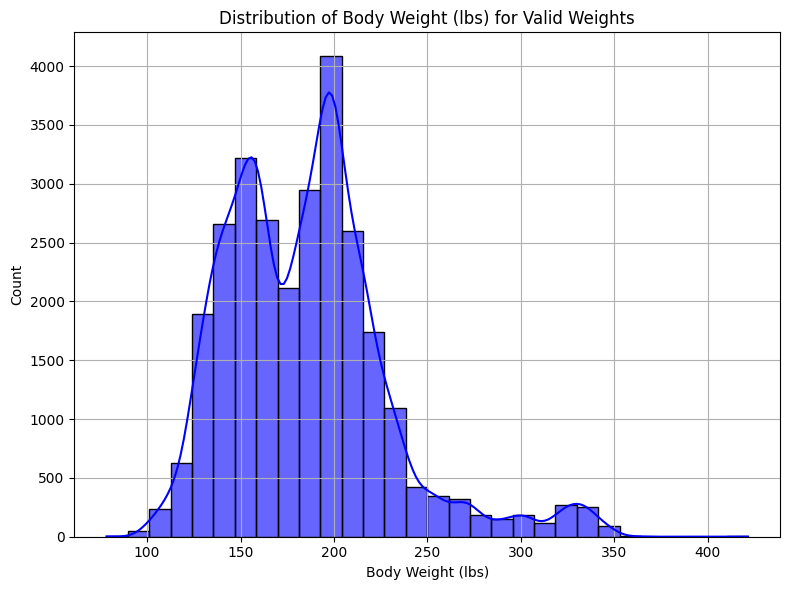

In [16]:
# valid_weights = data.dropna(subset=['BODY_WEIGHT_LBS', 'initial_value'])

plt.figure(figsize=(8,6))
sns.histplot(valid_weights['BODY_WEIGHT_LBS'], bins=30, kde=True, color='blue', alpha=0.6)

plt.xlabel('Body Weight (lbs)')
plt.ylabel('Count')
plt.title('Distribution of Body Weight (lbs) for Valid Weights')
plt.grid(True)
plt.tight_layout()

plt.show()


In [17]:
team_avg_weights = valid_weights.groupby('Team')['BODY_WEIGHT_LBS'].mean()

team_avg_weights


Team
Acro and Tumbling     135.600937
Baseball              204.185912
Football              231.332221
Lacrosse              145.853444
Men's Basketball      204.831445
Men's Golf            163.880343
Men's Tennis          176.308581
Soccer                148.152492
Softball              164.732350
Track and Field       159.294819
Volleyball            168.206436
Volleyball Beach      156.124911
Women's Basketball    176.124388
Women's Golf          143.445805
Women's Tennis        141.615795
Name: BODY_WEIGHT_LBS, dtype: float64

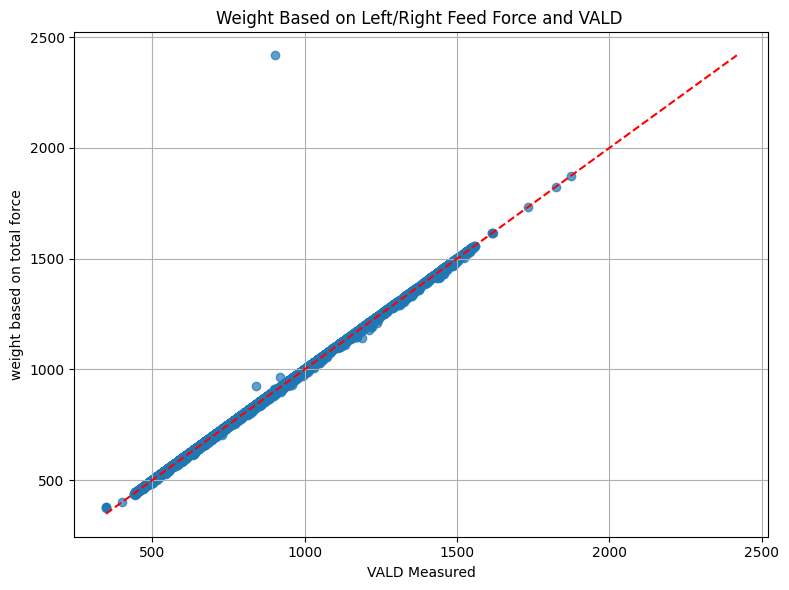

In [18]:

plt.figure(figsize=(8,6))
plt.scatter(valid_weights['body_weight_newtons'], valid_weights['initial_value'], alpha=0.7)

min_val = min(valid_weights['body_weight_newtons'].min(), valid_weights['initial_value'].min())
max_val = max(valid_weights['body_weight_newtons'].max(), valid_weights['initial_value'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Match (y=x)')
plt.title("Weight Based on Left/Right Feed Force and VALD ")
plt.xlabel('VALD Measured')
plt.ylabel('weight based on total force')
plt.grid(True)
plt.tight_layout()

plt.show()


In [19]:
data['missing_body_weight'] = data['BODY_WEIGHT_LBS'].isna()


/tmp/ipykernel_3202/1141006229.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['missing_body_weight'] = data['BODY_WEIGHT_LBS'].isna()


In [20]:
missing_by_year = data.groupby('year')['missing_body_weight'].mean() * 100
print(missing_by_year)


year
2017    0.0
2018    0.0
2019    0.0
2020    0.0
2021    0.0
2022    0.0
2023    0.0
2024    0.0
2025    0.0
Name: missing_body_weight, dtype: float64


In [21]:
jump_over_600 = data[data["jump_end_time"] >= .600]
jump_over_600 = jump_over_600.reset_index()

jump_under_600 = data[data["jump_end_time"] < .600]
jump_under_600 = jump_under_600.reset_index()


In [22]:
print("Count of Jumps Over 600ms per year:")
print(jump_over_600['start_year'].value_counts().sort_index())

print("\nCount of Jumps Under 600ms per year:")
print(jump_under_600['start_year'].value_counts().sort_index())

Count of Jumps Over 600ms per year:
2017    468
2018    160
2019    838
2020    789
2021    808
2022     49
2023     12
2024      1
Name: start_year, dtype: int64

Count of Jumps Under 600ms per year:
2017      19
2018       6
2019       4
2020      48
2021     628
2022    9422
2023    9126
2024    5743
2025     156
Name: start_year, dtype: int64


In [23]:
data.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series,latent_space_consistency,reconstruction_loss,reconstruction,outlier,total_sessions,start_year,years_training,first_session_date,relative_session,latent_0,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,latent_11,latent_12,latent_13,latent_14,latent_15,initial_weight,year,jump_start,jump_end,jump_duration_s,jump_end_time,Gender,missing_body_weight
0,0,0,f6b0b4f3-ccaa-488c-b71b-2a9d6fd8c359,1,eb037fd9-1b41-4bee-ade5-079f3d3012f8,2023-01-06 23:31:43.937000+00:00,Acro and Tumbling,Sport,NaN,NaN,121.271038,10.206,10.628,10.37,10.46,18.494496,10.206,8.676187,8.861041,0.424,22.037504,22.51405,22.507032,40.056,result\nPOSITIVE_IMPULSE 305.515939\nPOSITI...,2013.020207,124.807,result\nLANDING_RFD 44361.941\nLANDING_RFD ...,1.851,242.302,-0.095,40.056,result\nPEAK_LANDING_FORCE 2750.440318\nPEA...,3826.224,0.389,49.86295,result\nLANDING_IMPULSE 74.115300\nLANDING_...,35920.0,result\nMEAN_ECCENTRIC_FORCE 541.478054\nME...,216.720458,3.928942,57.900625,result\nECCENTRIC_BRAK

/tmp/ipykernel_3202/2351612344.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["time_diff"] = abs(data["jump_duration_s"] - data["jump_end_time"])


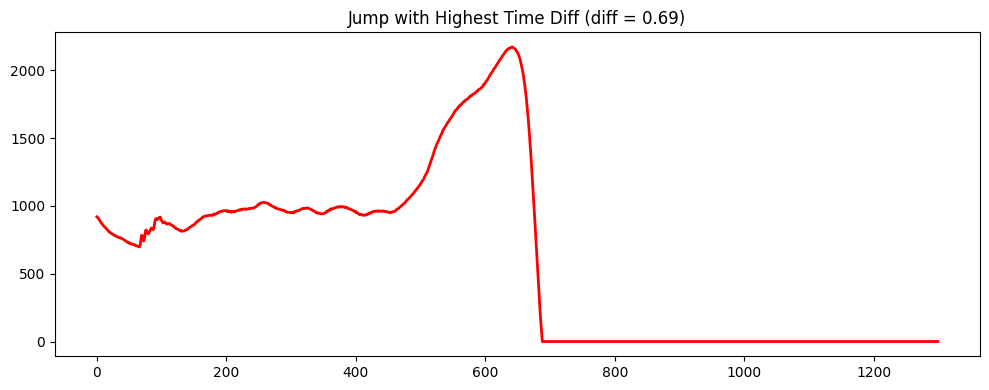

Unnamed: 0.1                                           2050
Unnamed: 0                                             2050
testID                 dc2cdbc3-c182-41d9-9fbc-11eb11c834e0
rep                                                       1
profileID              e2690c7a-bcd5-4105-bef9-de5362da4986
                                       ...                 
jump_duration_s                                       1.378
jump_end_time                                         0.687
Gender                                                 Male
missing_body_weight                                   False
time_diff                                             0.691
Name: 17239, Length: 166, dtype: object

In [24]:
data["time_diff"] = abs(data["jump_duration_s"] - data["jump_end_time"])
max_diff_row = data.loc[data["time_diff"].idxmax()]

time_series = max_diff_row["total_force"]

plt.figure(figsize=(10, 4))
plt.plot(time_series, color="red", linewidth=2)
plt.title(f'Jump with Highest Time Diff (diff = {max_diff_row["time_diff"]:.2f})')
plt.tight_layout()
plt.show()
max_diff_row

In [25]:
# data[data["profileID"] == "325e4dc3-58f5-4635-ae78-86eea00ad00d"]

<AxesSubplot: xlabel='jump_duration_s', ylabel='jump_end_time'>

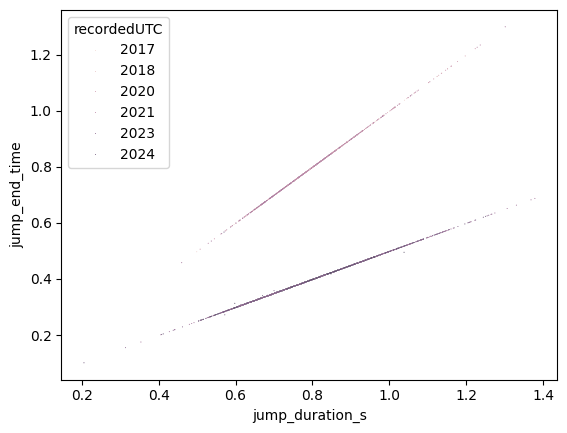

In [26]:
sns.scatterplot(x=data["jump_duration_s"], y=data["jump_end_time"],hue=pd.to_datetime(data["recordedUTC"]).dt.year, s=0.5)

In [27]:
data["takeoff_velocity"] = data.apply(
    lambda row: np.mean(np.array(row["downsampled_time_series"]) - 1) * row["jump_end_time"] * 9.81, axis=1
)
data["takeoff_velocity_2"] = data.apply(
    lambda row: np.mean(np.array(row["downsampled_time_series"]) - 1) * row["jump_duration_s"] * 9.81, axis=1
)

data["tv_jump_height"] = ((data["takeoff_velocity"] ** 2) / (2 * 9.81)) * 39.37
data["tv_jump_height_2"] = ((data["takeoff_velocity_2"] ** 2) / (2 * 9.81)) * 39.37

/tmp/ipykernel_3202/588924060.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["takeoff_velocity"] = data.apply(
/tmp/ipykernel_3202/588924060.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["takeoff_velocity_2"] = data.apply(
/tmp/ipykernel_3202/588924060.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/

In [28]:
np.mean(data["tv_jump_height"]), np.mean(data["JUMP_HEIGHT_INCHES_IMP_MOM"])

(4.797120717481005, 14.214819020970955)

In [29]:
under_5 = data[data["tv_jump_height"] <= 7]
under_5 = under_5.reset_index()
over_20 = data[data["tv_jump_height"] > 7]
over_20 = over_20.reset_index()

In [30]:
under_5["Team"].unique()


array(['Acro and Tumbling', 'Baseball', 'Football', 'Lacrosse',
       "Men's Basketball", "Men's Golf", "Men's Tennis", 'Soccer',
       'Softball', 'Track and Field', 'Volleyball Beach', 'Volleyball',
       "Women's Basketball", "Women's Golf", "Women's Tennis"],
      dtype=object)

In [31]:
over_20["Team"].unique()

array(['Acro and Tumbling', 'Baseball', 'Football', 'Lacrosse',
       "Men's Basketball", 'Soccer', 'Softball', 'Track and Field',
       'Volleyball Beach', "Women's Basketball", "Women's Tennis"],
      dtype=object)

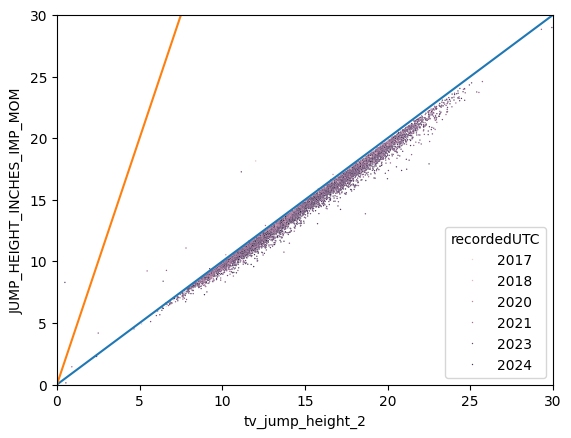

In [32]:
sns.scatterplot(x=data["tv_jump_height_2"], y=data["JUMP_HEIGHT_INCHES_IMP_MOM"], hue=pd.to_datetime(data["recordedUTC"]).dt.year,s=1)
plt.xlim((0,30))
plt.ylim((0, 30))
plt.plot((0, 30), (0, 30))
plt.plot((0, 30), (0, 120))


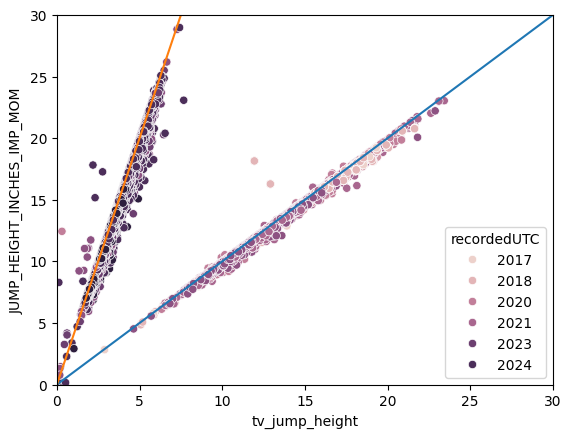

In [33]:
sns.scatterplot(x=data["tv_jump_height"], y=data["JUMP_HEIGHT_INCHES_IMP_MOM"], hue=pd.to_datetime(data["recordedUTC"]).dt.year)
plt.xlim((0,30))
plt.ylim((0, 30))
plt.plot((0, 30), (0, 30))
plt.plot((0, 30), (0, 120))


males = data[data["Gender"] == "Male"]
females = data[data["Gender"] == "Female"]

In [34]:
# males.head(1)



In [35]:
X_latent_4d = np.stack(males["vae_latent_space_4d"].values)
latent_df = pd.DataFrame(X_latent_4d, columns=["latent_1", "latent_2", "latent_3", "latent_4"])

latent_df["jump_duration_s"] = males["jump_duration_s"].values
corr_df = latent_df.dropna()

correlation_matrix = corr_df.corr()

print(correlation_matrix["jump_duration_s"])


plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix: Latent Variables & Jump Duration")
plt.tight_layout()
plt.show()


NameError: name 'males' is not defined

In [ ]:
import statsmodels.api as sm

X_latent_4d = np.stack(males["vae_latent_space_4d"].values)
X_df = pd.DataFrame(X_latent_4d).reset_index(drop=True)

y = males["JUMP_HEIGHT_INCHES"].reset_index(drop=True)

X_with_const = sm.add_constant(X_df)

valid_idx = X_with_const.notna().all(axis=1) & y.notna()
X_clean = X_with_const[valid_idx]
y_clean = y[valid_idx]

model = sm.OLS(y_clean, X_clean).fit()
print(model.summary())




### Using jump duration in seconds and 4d latent space as predictors of jump height (MALES)

In [ ]:
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

model_df = males.dropna(subset=["jump_duration_s", "JUMP_HEIGHT_INCHES", "vae_latent_space_4d"])

X_latent = np.stack(model_df["vae_latent_space_4d"].values)
X = np.hstack([X_latent, model_df[["jump_duration_s"]].values])
y = model_df["JUMP_HEIGHT_INCHES"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"Test RMSE: {rmse:.2f} inches")

print("Coefficients (latent_1 to latent_4, then jump_duration_s):", model.coef_)


In [ ]:
y_pred = model.predict(X_test)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel("Actual Jump Height (inches)")
plt.ylabel("Predicted Jump Height (inches)")
plt.title("Actual vs. Predicted Jump Height")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
y_pred_all = model.predict(X)
model_df["predicted_jump_height"] = y_pred_all
model_df["residual"] = model_df["JUMP_HEIGHT_INCHES"] - model_df["predicted_jump_height"]

top_over = model_df.sort_values(by="residual", ascending=False).head(5)
top_under = model_df.sort_values(by="residual", ascending=True).head(5)

print("Top Overperformers:\n", top_over[["JUMP_HEIGHT_INCHES", "predicted_jump_height", "residual"]])
print("\nTop Underperformers:\n", top_under[["JUMP_HEIGHT_INCHES", "predicted_jump_height", "residual"]])


In [ ]:
def plot_force_curves(df, title):
    plt.figure(figsize=(10, 6))
    for i, (_, row) in enumerate(df.iterrows()):
        force = row["downsampled_time_series"]
        label = (
            f"Jump {i+1} | Height: {row['JUMP_HEIGHT_INCHES']:.2f} | Duration: {row['jump_duration_s']:.2f}s "
            f"| Residual: {row['residual']:.2f}\""
        )
        plt.plot(force, label=label, alpha=0.7)
    plt.title(title)
    plt.xlabel("Time (samples)")
    plt.ylabel("Total Force (N)")
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_force_curves(top_over, "Total Force Curves - Top Overperformers")

plot_force_curves(top_under, "Total Force Curves - Top Underperformers")

In [ ]:
latent_vals = np.stack(model_df["vae_latent_space_4d"].values)
min_vals = latent_vals.min(axis=0)
max_vals = latent_vals.max(axis=0)
duration_min = model_df["jump_duration_s"].min()
duration_max = model_df["jump_duration_s"].max()

print("Latent min/max:", min_vals, max_vals)
print("Duration range:", duration_min, duration_max)


In [ ]:
X_latent = np.stack(model_df["vae_latent_space_4d"].values)
X = np.hstack([X_latent, model_df[["jump_duration_s"]].values])
y = model_df["JUMP_HEIGHT_INCHES"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)

latent_vec = [-2.47, 2.22, -2.29, 2.92]

print(f"Ideal vector is {latent_vec}")

x1 = float(input("Enter a number for Latent 1: "))
x2 = float(input("Enter a number for Latent 2: "))
x3 = float(input("Enter a number for Latent 3: "))
x4 = float(input("Enter a number for Latent 4: "))
latent_vec_2  = [x1, x2, x3, x4]

mean_jump_duration = model_df["jump_duration_s"].mean()  # USING THE MEAN JUMP DURATION


X_optimal = np.hstack([latent_vec, [mean_jump_duration]])
X_input = np.hstack([latent_vec_2, [mean_jump_duration]])

predicted_jump_optimal = model.predict([X_optimal])[0]
predicted_jump_input = model.predict([X_input])[0]

print(f"Predicted Jump Height for Optimal Latent Vector: {predicted_jump_optimal:.2f} inches")
print(f"Predicted Jump Height for User Input Latent Vector: {predicted_jump_input:.2f} inches")

# Reconstruct the force curves
vae.eval()

latent_tensor = torch.tensor(latent_vec, dtype=torch.float32).unsqueeze(0)
latent_tensor_2 = torch.tensor(latent_vec_2, dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    reconstructed = vae.decode(latent_tensor).squeeze().cpu().numpy()
    reconstructed_2 = vae.decode(latent_tensor_2).squeeze().cpu().numpy()

plt.figure(figsize=(10, 4))
plt.plot(reconstructed, label="Optimal Latent Vector")
plt.plot(reconstructed_2, label="User Input Latent Vector")
plt.title("Reconstructed Force Curves")
plt.xlabel("Time (samples)")
plt.ylabel("Total Force (N)")
plt.grid(True)
plt.legend()  
plt.tight_layout()
plt.show()


In [ ]:
# minimal change in latent space to get 1 inch increase in jump height
# 

In [ ]:
from scipy.optimize import differential_evolution

# Same bounds
bounds = [
    (-2.47, 2.10),  # latent_1
    (-1.83, 2.22),  # latent_2
    (-2.29, 3.79),  # latent_3
    (-2.96, 2.92),  # latent_4
    (0.51, 1.07)    # jump_duration_s
]

# Minimization (remove the negative sign)
def objective_min(vec):
    return model.predict([vec])[0]

# Run optimization
result_min = differential_evolution(objective_min, bounds, seed=42)

# Extract results
worst_vec = result_min.x
min_pred = result_min.fun

print("Realistic worst latent vector + duration:", worst_vec)
print("Min predicted jump height (constrained):", min_pred)


In [ ]:
import torch
import matplotlib.pyplot as plt

# Extract latent vector (first 4 elements)
worst_latent = torch.tensor(worst_vec[:4], dtype=torch.float32).unsqueeze(0)

# Decode to get the reconstructed force curve
vae.eval()
with torch.no_grad():
    reconstructed_force = vae.decode(worst_latent).cpu().numpy().squeeze()

# Plot the reconstructed force curve
plt.figure(figsize=(10, 4))
plt.plot(reconstructed_force, label="Worst-case Predicted Force Curve")
plt.title("Reconstructed Force Curve from Worst-case Latent Vector")
plt.xlabel("Time (samples)")
plt.ylabel("Total Force (N)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
data.head(1)

In [ ]:
athlete_data = model_df.iloc[0]  
latent_vec = np.array(athlete_data["vae_latent_space_4d"])
jump_duration = athlete_data["jump_duration_s"]

features = np.hstack([latent_vec, jump_duration])
predicted_jump = model.predict([features])[0]

print(f"Current Predicted Jump Height: {predicted_jump:.2f} inches")


In [ ]:
improved_jump_duration = jump_duration + .05
features_improved = np.hstack([latent_vec, improved_jump_duration])
predicted_improved = model.predict([features_improved])[0]

print(f"Predicted Jump Height with +5ms Duration: {predicted_improved:.2f} inches")


In [ ]:
for i, coef in enumerate(model.coef_):
    label = f"latent_{i+1}" if i < 4 else "jump_duration_s"
    print(f"{label}: {coef:.2f}")


In [ ]:
latent_grid = [latent_vec + np.random.normal(0, 0.05, size=4) for _ in range(100)]
jump_times = np.linspace(jump_duration, jump_duration + .10, 20)

best_jump = -np.inf
best_config = None

for latents in latent_grid:
    for jt in jump_times:
        features = np.hstack([latents, jt])
        pred = model.predict([features])[0]
        if pred > best_jump:
            best_jump = pred
            best_config = (latents, jt)

print(f"Best predicted jump: {best_jump:.2f} inches at jump_duration = {best_config[1]:.2f} ms")


In [ ]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

X_dur = model_df["jump_duration_s"].values.reshape(-1, 1)
y_jump = model_df["JUMP_HEIGHT_INCHES"].values

poly = PolynomialFeatures(degree=3)  # You can adjust degree
X_poly = poly.fit_transform(X_dur)

poly_model = LinearRegression()
poly_model.fit(X_poly, y_jump)

# Predict over a smooth range
dur_range = np.linspace(X_dur.min(), X_dur.max(), 200).reshape(-1, 1)
height_pred = poly_model.predict(poly.transform(dur_range))

plt.scatter(X_dur, y_jump, alpha=0.3, label='Data')
plt.plot(dur_range, height_pred, color='red', label='Polynomial Fit')
plt.xlabel("Jump Duration (ms)")
plt.ylabel("Jump Height (inches)")
plt.title("Polynomial Fit: Jump Height vs. Duration")
plt.legend()
plt.show()


In [ ]:
optimal_range = (0.75, 0.95)
min_jump_height = 20  

underutilizers = model_df[
    (model_df["jump_duration_s"] < optimal_range[0]) &
    (model_df["JUMP_HEIGHT_INCHES"] < min_jump_height)
]

print(f"Number of underutilized jumpers: {len(underutilizers)}")


In [ ]:
latent_vec = np.stack(underutilizers["vae_latent_space_4d"].values)
durations = underutilizers["jump_duration_s"].values.reshape(-1, 1)
X_improved = np.hstack([latent_vec, durations + 0.05])  # Simulate +50ms
predicted_gain = model.predict(X_improved) - underutilizers["JUMP_HEIGHT_INCHES"].values

underutilizers["potential_gain_inches"] = predicted_gain


In [ ]:
# underutilizers

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Jump Height")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot for Linear Regression")
plt.grid(True)
plt.tight_layout()
plt.show()
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(X_train, y_train)

y_poly_pred = poly_model.predict(X_test)
rmse_poly = mean_squared_error(y_test, y_poly_pred, squared=False)
print(f"Polynomial Regression (deg=2) RMSE: {rmse_poly:.2f} inches")


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_rf_pred = rf.predict(X_test)
rmse_rf = mean_squared_error(y_test, y_rf_pred, squared=False)
print(f"Random Forest RMSE: {rmse_rf:.2f} inches")


### FEMALES

In [ ]:
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

model_df = females.dropna(subset=["jump_duration_s", "JUMP_HEIGHT_INCHES", "vae_latent_space_4d"])

X_latent = np.stack(model_df["vae_latent_space_4d"].values)
X = np.hstack([X_latent, model_df[["jump_duration_s"]].values])
y = model_df["JUMP_HEIGHT_INCHES"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"Test RMSE: {rmse:.2f} inches")

print("Coefficients (latent_1 to latent_4, then jump_duration_s):", model.coef_)


In [ ]:
y_pred = model.predict(X_test)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel("Actual Jump Height (inches)")
plt.ylabel("Predicted Jump Height (inches)")
plt.title("Actual vs. Predicted Jump Height")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
y_pred_all = model.predict(X)
model_df["predicted_jump_height"] = y_pred_all
model_df["residual"] = model_df["JUMP_HEIGHT_INCHES"] - model_df["predicted_jump_height"]

top_over = model_df.sort_values(by="residual", ascending=False).head(5)
top_under = model_df.sort_values(by="residual", ascending=True).head(5)

print("Top Overperformers:\n", top_over[["JUMP_HEIGHT_INCHES", "predicted_jump_height", "residual"]])
print("\nTop Underperformers:\n", top_under[["JUMP_HEIGHT_INCHES", "predicted_jump_height", "residual"]])


In [ ]:
def plot_force_curves(df, title):
    plt.figure(figsize=(10, 6))
    for i, (_, row) in enumerate(df.iterrows()):
        force = row["downsampled_time_series"]
        label = (
            f"Jump {i+1} | Height: {row['JUMP_HEIGHT_INCHES']:.2f} | Duration: {row['jump_duration_s']:.2f}s "
            f"| Residual: {row['residual']:.2f}\""
        )
        plt.plot(force, label=label, alpha=0.7)
    plt.title(title)
    plt.xlabel("Time (samples)")
    plt.ylabel("Total Force (N)")
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_force_curves(top_over, "Total Force Curves - Top Overperformers")

plot_force_curves(top_under, "Total Force Curves - Top Underperformers")

In [ ]:
athlete_data = model_df.iloc[0]  
latent_vec = np.array(athlete_data["vae_latent_space_4d"])
jump_duration = athlete_data["jump_duration_s"]

features = np.hstack([latent_vec, jump_duration])
predicted_jump = model.predict([features])[0]

print(f"Current Predicted Jump Height: {predicted_jump:.2f} inches")


In [ ]:
improved_jump_duration = jump_duration + .05
features_improved = np.hstack([latent_vec, improved_jump_duration])
predicted_improved = model.predict([features_improved])[0]

print(f"Predicted Jump Height with +5ms Duration: {predicted_improved:.2f} inches")


In [ ]:
for i, coef in enumerate(model.coef_):
    label = f"latent_{i+1}" if i < 4 else "jump_duration_s"
    print(f"{label}: {coef:.2f}")


In [36]:
males = data[data["Gender"] == "Male"]
females = data[data["Gender"] == "Female"]

In [37]:
len(males[(males["JUMP_HEIGHT_INCHES"] > 24) & (males["outlier"] == 0)])

488

In [38]:
males = males[males["outlier"] == 0]
rep_counts = males.groupby("testID")["profileID"].count()
low_rep_testIDs = rep_counts[rep_counts < 2].index
males.loc[males["testID"].isin(low_rep_testIDs), "outlier"] = 1
males["outlier"] = (males["JUMP_HEIGHT_INCHES"] < 5).astype(int)

high_start_mask = males["downsampled_time_series"].apply(lambda x: np.any(np.array(x[20:31]) > 1))

low_air_mask = males["downsampled_time_series"].apply(lambda x: np.any(np.array(x[60:81]) < 1.6))

males.loc[high_start_mask | low_air_mask, "outlier"] = 1

males_clean = males[males["outlier"] == 0].copy()
males = males_clean


In [39]:
len(males[(males["JUMP_HEIGHT_INCHES"] > 24) & (males["outlier"] == 0)])

473

In [40]:
females = females[females["outlier"] == 0]

rep_counts_female = females.groupby("testID")["profileID"].count()
low_rep_testIDs_female = rep_counts_female[rep_counts_female < 2].index
females.loc[females["testID"].isin(low_rep_testIDs_female), "outlier"] = 1

females["outlier"] = (females["JUMP_HEIGHT_INCHES"] < 5).astype(int)

high_start_mask_female = females["downsampled_time_series"].apply(lambda x: np.any(np.array(x[20:31]) > 1))
low_air_mask_female = females["downsampled_time_series"].apply(lambda x: np.any(np.array(x[60:81]) < 1.6))

females.loc[high_start_mask_female | low_air_mask_female, "outlier"] = 1

females_clean = females[females["outlier"] == 0].copy()
females = females_clean

In [41]:
male_downsampled_data = males['downsampled_time_series'].values

male_downsampled_tensor = torch.tensor(male_downsampled_data.tolist(), dtype=torch.float32).to(device)

female_downsampled_data = females['downsampled_time_series'].values

female_downsampled_tensor = torch.tensor(female_downsampled_data.tolist(), dtype=torch.float32).to(device)

In [42]:
def get_latent_stats(vae, data_tensor):
    vae.eval()
    with torch.no_grad():
        mean, logvar = vae.encode(data_tensor)
        std = torch.exp(0.5 * logvar)
        z = vae.reparameterization(mean, std)
    return mean.cpu().numpy(), std.cpu().numpy(), z.cpu().numpy()


In [43]:
male_means, male_stds, male_latents = get_latent_stats(vae, male_downsampled_tensor)
female_means, female_stds, female_latents = get_latent_stats(vae, female_downsampled_tensor)

In [44]:
males["vae_latent_space_4d"] = list(male_means)
females["vae_latent_space_4d"] = list(female_means)

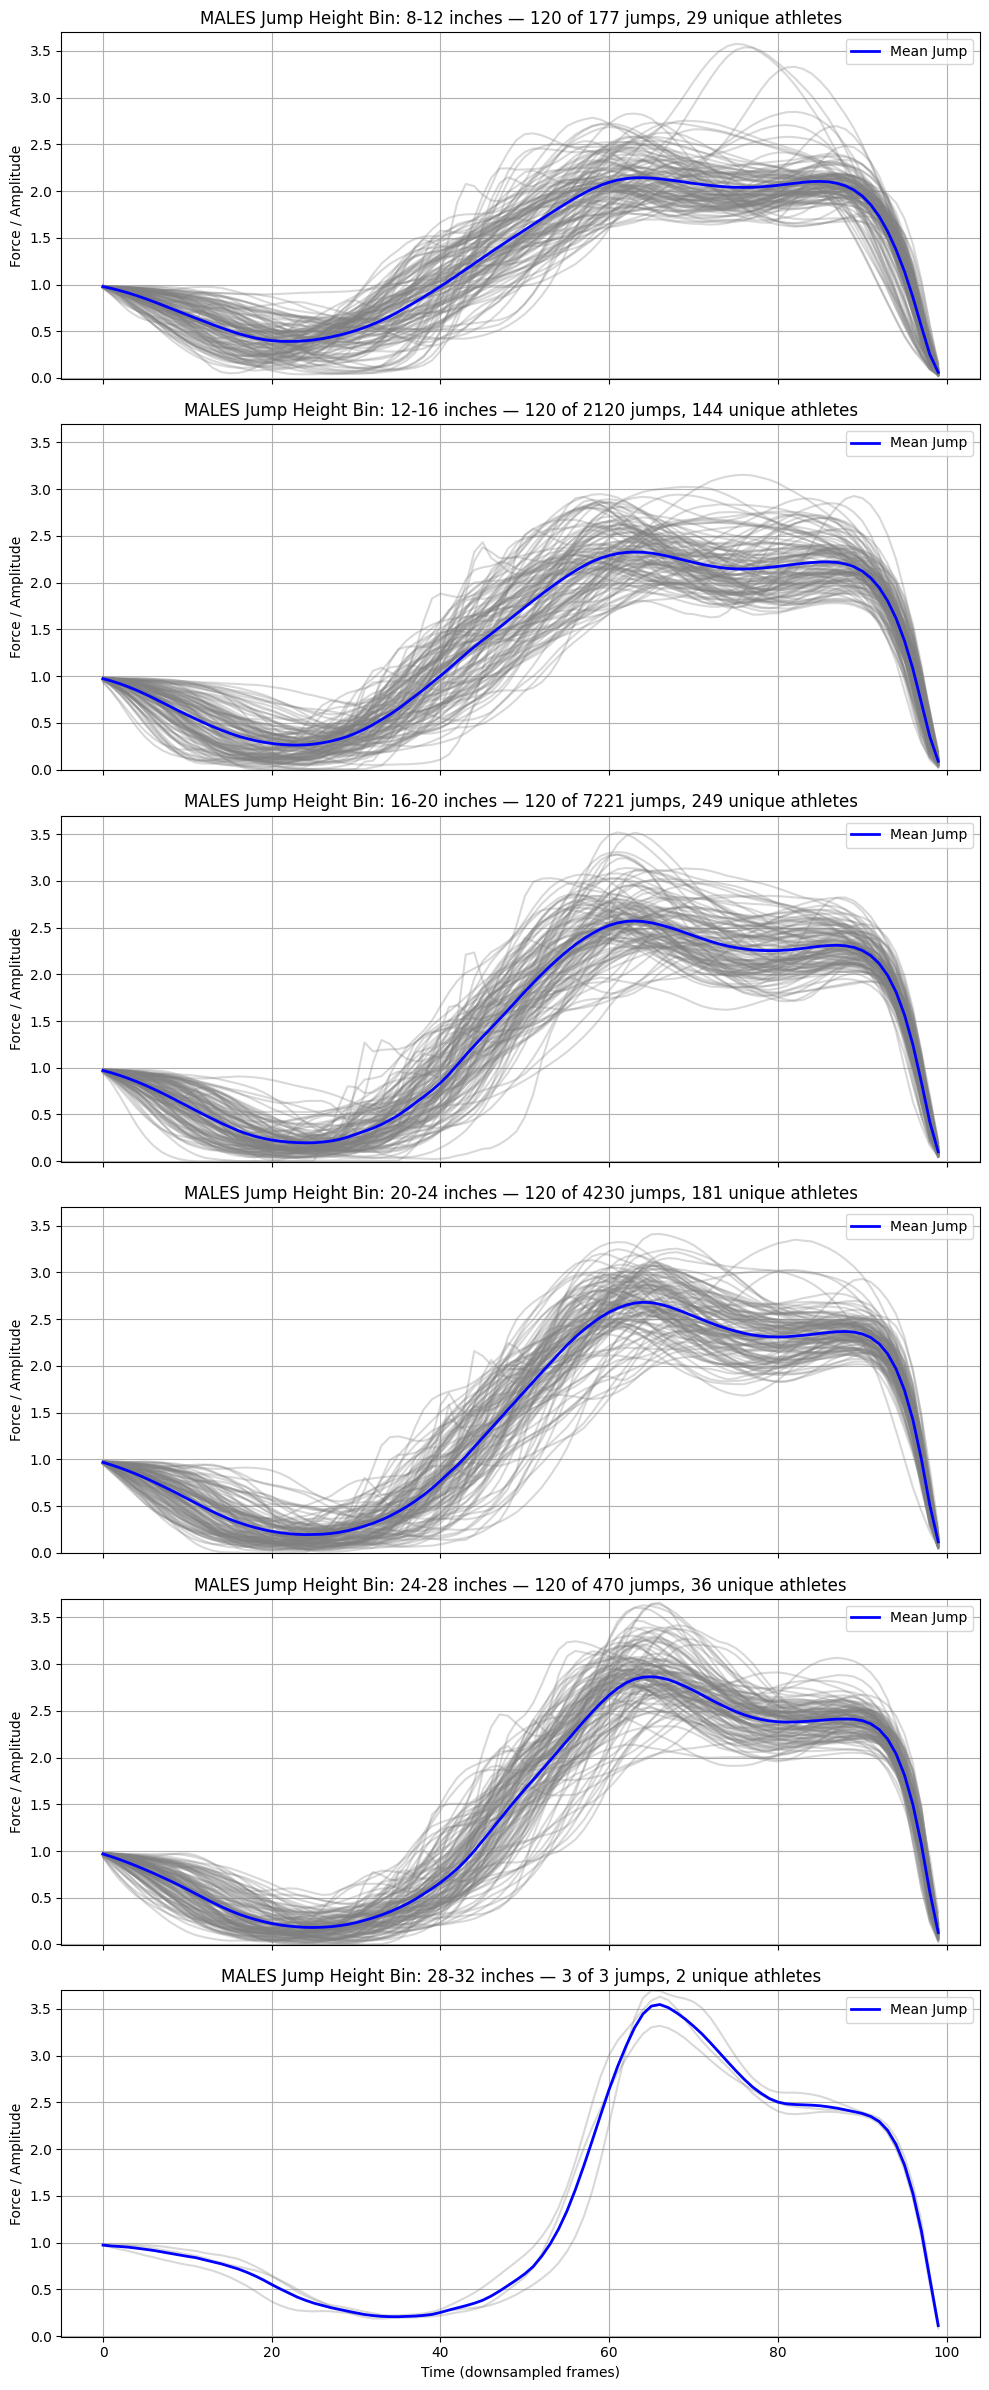

In [45]:
import math
from pandas.api.types import CategoricalDtype

BIN_SIZE = 4  # inches per bin
MAX_JUMPS_PER_BIN = 120  # max jumps to sample per bin

# Filter and bin
binned_males = males.dropna(subset=["JUMP_HEIGHT_INCHES", "downsampled_time_series"])
binned_males = binned_males[binned_males["JUMP_HEIGHT_INCHES"] > 6]

min_height = math.floor(binned_males["JUMP_HEIGHT_INCHES"].min())
max_height = math.ceil(binned_males["JUMP_HEIGHT_INCHES"].max())
bins = np.arange(min_height, max_height + BIN_SIZE, BIN_SIZE)
bin_labels = [f"{int(b)}-{int(b + BIN_SIZE)}" for b in bins[:-1]]

binned_males["jump_bin"] = pd.cut(
    binned_males["JUMP_HEIGHT_INCHES"],
    bins=bins,
    labels=bin_labels,
    include_lowest=True
)
cat_type = CategoricalDtype(categories=bin_labels, ordered=True)
binned_males["jump_bin"] = binned_males["jump_bin"].astype(cat_type)

unique_bins = sorted(binned_males["jump_bin"].dropna().unique(), key=lambda x: bin_labels.index(str(x)))
n_bins = len(unique_bins)

# Step 1: Determine global y-limits
y_min, y_max = np.inf, -np.inf
for bin_label in unique_bins:
    group = binned_males[binned_males["jump_bin"] == bin_label]
    group_sample = group.sample(n=min(MAX_JUMPS_PER_BIN, len(group)))
    try:
        jump_matrix = np.stack(group_sample["downsampled_time_series"].values)
        y_min = min(y_min, jump_matrix.min())
        y_max = max(y_max, jump_matrix.max())
    except Exception as e:
        print(f"Error computing global y-limits for bin {bin_label}: {e}")

# Step 2: Plot with consistent y-axis
fig, axes = plt.subplots(n_bins, 1, figsize=(10, 4 * n_bins), sharex=True)
if n_bins == 1:
    axes = [axes]  

for ax, bin_label in zip(axes, unique_bins):
    group = binned_males[binned_males["jump_bin"] == bin_label]
    group_sample = group.sample(n=min(MAX_JUMPS_PER_BIN, len(group)))  

    for _, row in group_sample.iterrows():
        ax.plot(row["downsampled_time_series"], color='gray', alpha=0.3)

    try:
        jump_matrix = np.stack(group_sample["downsampled_time_series"].values)
        mean_jump = jump_matrix.mean(axis=0)
        ax.plot(mean_jump, color='blue', linewidth=2, label='Mean Jump')
    except Exception as e:
        print(f"Skipping mean plot for bin {bin_label}: {e}")

    unique_athletes = group["profileID"].nunique()
    ax.set_title(
        f"MALES Jump Height Bin: {bin_label} inches — "
        f"{len(group_sample)} of {len(group)} jumps, "
        f"{unique_athletes} unique athletes"
    )
    ax.set_ylabel("Force / Amplitude")
    ax.set_ylim(y_min, y_max)
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Time (downsampled frames)")
plt.tight_layout()
plt.show()


In [46]:

len(binned_males[(binned_males["JUMP_HEIGHT_INCHES"] > 24) & (binned_males["outlier"] == 0)])
before = len(binned_males)
after = len(binned_males.dropna(subset=['jump_duration_s']))
print("Dropped due to NaNs:", before - after)
print(f"Before: {before}, After: {after}")

Dropped due to NaNs: 9547
Before: 14221, After: 4674


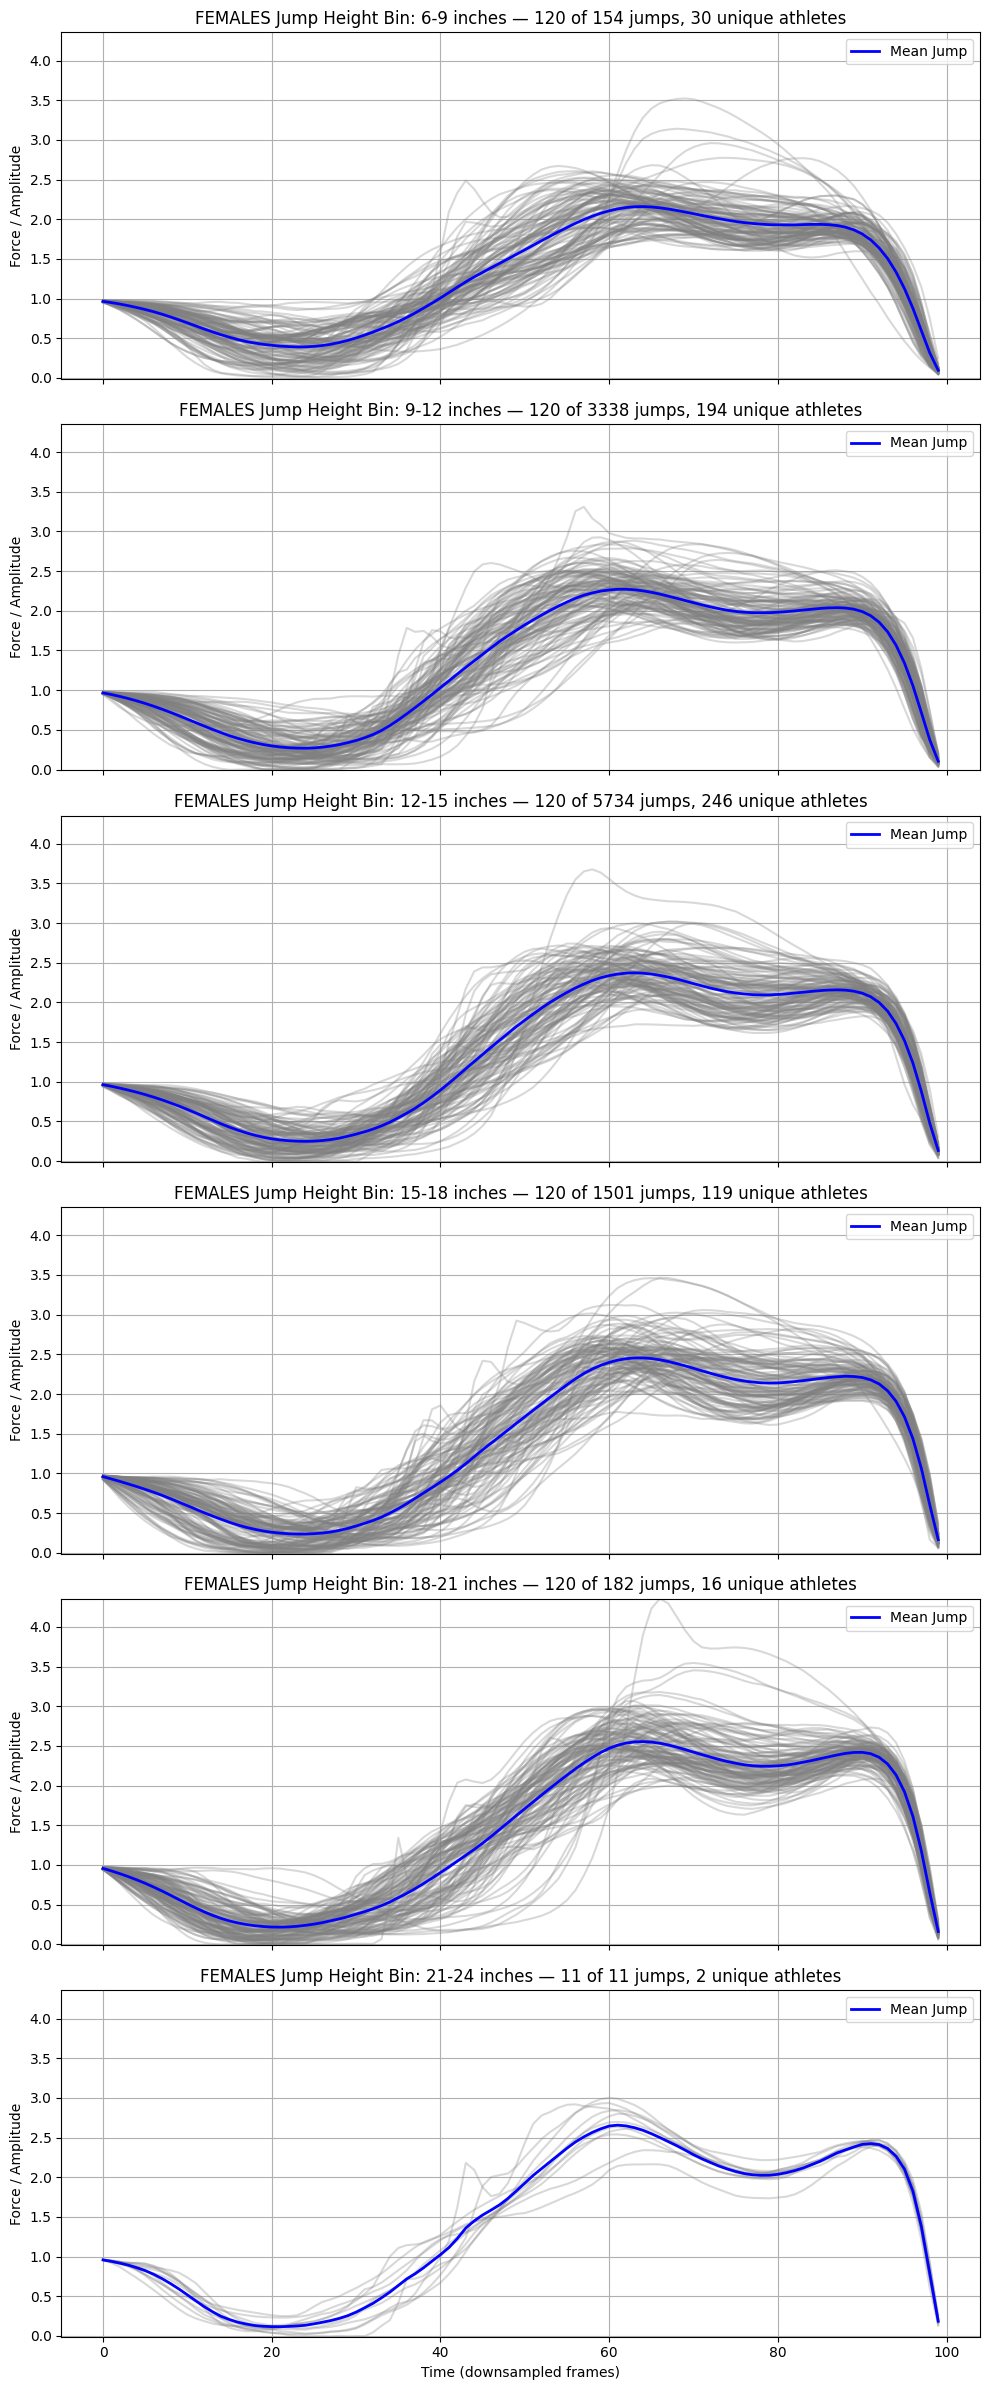

In [47]:
import math
from pandas.api.types import CategoricalDtype

BIN_SIZE = 3  # inches per bin
MAX_JUMPS_PER_BIN = 120  # max jumps to sample per bin

# Filter and bin
binned_females = females.dropna(subset=["JUMP_HEIGHT_INCHES", "downsampled_time_series"])
binned_females = binned_females[binned_females["JUMP_HEIGHT_INCHES"] > 6]

min_height = math.floor(binned_females["JUMP_HEIGHT_INCHES"].min())
max_height = math.ceil(binned_females["JUMP_HEIGHT_INCHES"].max())
bins = np.arange(min_height, max_height + BIN_SIZE, BIN_SIZE)
bin_labels = [f"{int(b)}-{int(b + BIN_SIZE)}" for b in bins[:-1]]

binned_females["jump_bin"] = pd.cut(
    binned_females["JUMP_HEIGHT_INCHES"],
    bins=bins,
    labels=bin_labels,
    include_lowest=True
)
cat_type = CategoricalDtype(categories=bin_labels, ordered=True)
binned_females["jump_bin"] = binned_females["jump_bin"].astype(cat_type)

unique_bins = sorted(binned_females["jump_bin"].dropna().unique(), key=lambda x: bin_labels.index(str(x)))
n_bins = len(unique_bins)

# Step 1: Determine global y-limits
y_min, y_max = np.inf, -np.inf
for bin_label in unique_bins:
    group = binned_females[binned_females["jump_bin"] == bin_label]
    group_sample = group.sample(n=min(MAX_JUMPS_PER_BIN, len(group)))
    try:
        jump_matrix = np.stack(group_sample["downsampled_time_series"].values)
        y_min = min(y_min, jump_matrix.min())
        y_max = max(y_max, jump_matrix.max())
    except Exception as e:
        print(f"Error computing global y-limits for bin {bin_label}: {e}")

# Step 2: Plot with consistent y-axis
fig, axes = plt.subplots(n_bins, 1, figsize=(10, 4 * n_bins), sharex=True)
if n_bins == 1:
    axes = [axes]  

for ax, bin_label in zip(axes, unique_bins):
    group = binned_females[binned_females["jump_bin"] == bin_label]
    group_sample = group.sample(n=min(MAX_JUMPS_PER_BIN, len(group)))  

    for _, row in group_sample.iterrows():
        ax.plot(row["downsampled_time_series"], color='gray', alpha=0.3)

    try:
        jump_matrix = np.stack(group_sample["downsampled_time_series"].values)
        mean_jump = jump_matrix.mean(axis=0)
        ax.plot(mean_jump, color='blue', linewidth=2, label='Mean Jump')
    except Exception as e:
        print(f"Skipping mean plot for bin {bin_label}: {e}")

    unique_athletes = group["profileID"].nunique()
    ax.set_title(
        f"FEMALES Jump Height Bin: {bin_label} inches — "
        f"{len(group_sample)} of {len(group)} jumps, "
        f"{unique_athletes} unique athletes"
    )
    ax.set_ylabel("Force / Amplitude")
    ax.set_ylim(y_min, y_max)
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Time (downsampled frames)")
plt.tight_layout()
plt.show()


In [48]:
len(binned_males[(binned_males["JUMP_HEIGHT_INCHES"] > 24) & (binned_males["outlier"] == 0)])

473

In [49]:
# import math

# BIN_SIZE = 4  # inches per bin
# binned_males = binned_males.dropna(subset=['jump_duration_s'])

# min_height = math.floor(binned_males["JUMP_HEIGHT_INCHES"].min())
# max_height = math.ceil(binned_males["JUMP_HEIGHT_INCHES"].max())
# bins = np.arange(min_height, max_height + BIN_SIZE, BIN_SIZE)
# bin_labels = [f"{int(b)}-{int(b + BIN_SIZE)}" for b in bins[:-1]]

# n_bootstrap = 1000
# means = []
# ci_lowers = []
# ci_uppers = []
# labels = []
# sample_means = []

# jump_end_means = []
# jump_end_ci_lowers = []
# jump_end_ci_uppers = []

# for idx, bin_label in enumerate(bin_labels):
#     group = binned_males[binned_males["jump_bin"] == bin_label]

#     if group.empty:
#         continue
#     sample_means.append(group["vae_latent_space_4d"].mean())

#     latent_matrix = np.stack(group["vae_latent_space_4d"].values)
#     n_total = latent_matrix.shape[0]
#     jump_end_array = group["jump_duration_s"].values

#     bootstrap_spreads = []
#     for _ in range(n_bootstrap):
#         sampled_indices = np.random.choice(n_total, size=n_total, replace=True)
#         sample = latent_matrix[sampled_indices]
#         sample_mean = sample.mean(axis=0)
#         distances = np.linalg.norm(sample - sample_mean, axis=1)
#         bootstrap_spreads.append(distances.mean())

#     means.append(np.mean(bootstrap_spreads))
#     ci_lowers.append(np.percentile(bootstrap_spreads, 2.5))
#     ci_uppers.append(np.percentile(bootstrap_spreads, 97.5))
#     labels.append(bin_label)

#     jump_end_boots = []
#     for _ in range(n_bootstrap):
#         sampled = np.random.choice(jump_end_array, size=n_total, replace=True)
#         jump_end_boots.append(sampled.mean())

#     jump_end_means.append(np.mean(jump_end_boots))
#     jump_end_ci_lowers.append(np.percentile(jump_end_boots, 2.5))
#     jump_end_ci_uppers.append(np.percentile(jump_end_boots, 97.5))

# # Plotting
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# # Latent space spread
# ax1.errorbar(labels, means,
#              yerr=[np.array(means) - np.array(ci_lowers), np.array(ci_uppers) - np.array(means)],
#              fmt='o', capsize=5, linestyle='None', color='b')

# for i, avg_end in enumerate(jump_end_means):
#     ax1.text(i, means[i] - 0.05, f"{avg_end:.3f}s", ha='center', fontsize=9, color='black')

# ax1.set_ylabel("Avg Distance to Mean (Latent Space)")
# ax1.set_title("MALES: Bootstrapped Spread per Jump Bin (Latent Space)\n(Annotated with Avg Jump Duration)")
# ax1.grid(True, axis='y')

# # Jump duration with clipped error bars to avoid negatives
# lower_errors = np.clip(np.array(jump_end_means) - np.array(jump_end_ci_lowers), 0, None)
# upper_errors = np.clip(np.array(jump_end_ci_uppers) - np.array(jump_end_means), 0, None)

# ax2.errorbar(labels, jump_end_means,
#              yerr=[lower_errors, upper_errors],
#              fmt='o', capsize=5, linestyle='None', color='green')

# ax2.set_ylabel("Avg Jump Duration (s)")
# ax2.set_xlabel("Jump Height Bin")
# ax2.set_title("MALES: Bootstrapped Avg Jump Duration per Bin (with 95% CI)")
# ax2.grid(True, axis='y')

# plt.tight_layout()
# plt.show()


In [50]:
len(binned_males[(binned_males["JUMP_HEIGHT_INCHES"] > 24) & (binned_males["outlier"] == 0)])

473

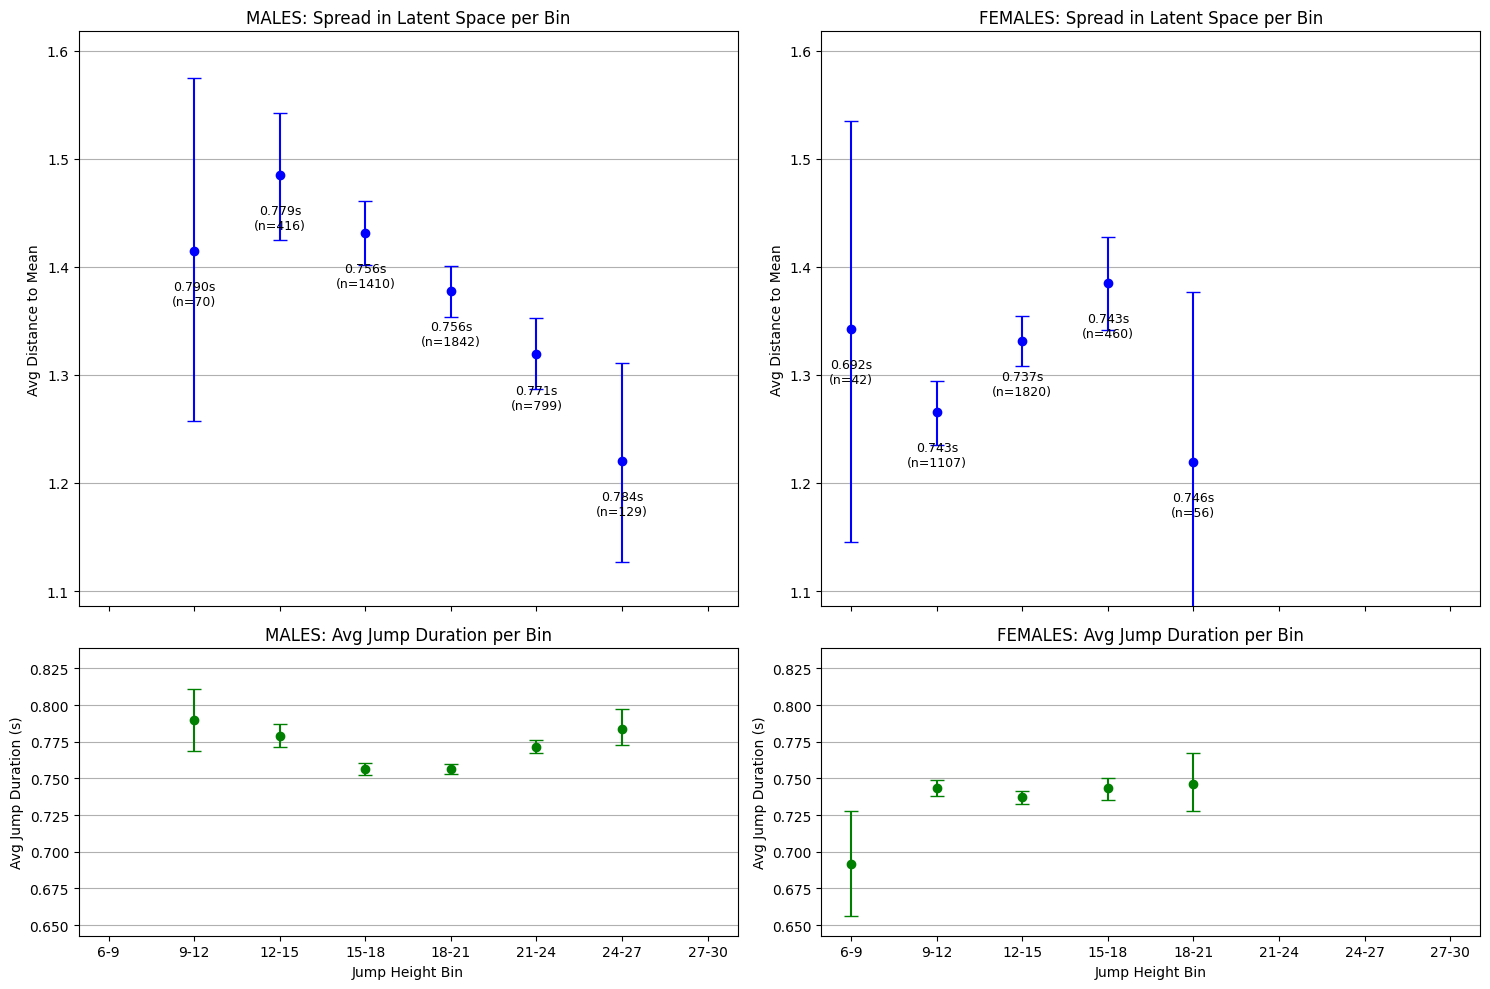

In [51]:
BIN_SIZE = 3  # inches per bin
n_bootstrap = 1000
MIN_SAMPLES = 40  # min samples per bin to include

binned_males = binned_males.dropna(subset=['jump_duration_s', 'JUMP_HEIGHT_INCHES', 'vae_latent_space_4d'])
binned_females = binned_females.dropna(subset=['jump_duration_s', 'JUMP_HEIGHT_INCHES', 'vae_latent_space_4d'])

min_height = math.floor(min(binned_males["JUMP_HEIGHT_INCHES"].min(), binned_females["JUMP_HEIGHT_INCHES"].min()))
max_height = math.ceil(max(binned_males["JUMP_HEIGHT_INCHES"].max(), binned_females["JUMP_HEIGHT_INCHES"].max()))
bins = np.arange(min_height, max_height + BIN_SIZE, BIN_SIZE)
bin_labels = [f"{int(b)}-{int(b + BIN_SIZE)}" for b in bins[:-1]]

binned_males["jump_bin"] = pd.cut(binned_males["JUMP_HEIGHT_INCHES"], bins=bins, labels=bin_labels, include_lowest=True)
binned_females["jump_bin"] = pd.cut(binned_females["JUMP_HEIGHT_INCHES"], bins=bins, labels=bin_labels, include_lowest=True)

def compute_bootstrap(data):
    results = {}

    for bin_label in bin_labels:
        group = data[data["jump_bin"] == bin_label]
        n_total = group.shape[0]

        if n_total < MIN_SAMPLES:
            results[bin_label] = None
            continue

        latent_matrix = np.stack(group["vae_latent_space_4d"].values)
        jump_end_array = group["jump_duration_s"].values

        # Bootstrap for latent space spread
        bootstrap_spreads = []
        for _ in range(n_bootstrap):
            sampled_indices = np.random.choice(n_total, size=n_total, replace=True)
            sample = latent_matrix[sampled_indices]
            sample_mean = sample.mean(axis=0)
            distances = np.linalg.norm(sample - sample_mean, axis=1)
            bootstrap_spreads.append(distances.mean())

        jump_end_boots = []
        for _ in range(n_bootstrap):
            sampled = np.random.choice(jump_end_array, size=n_total, replace=True)
            jump_end_boots.append(sampled.mean())

        results[bin_label] = {
            "mean": np.mean(bootstrap_spreads),
            "ci_lower": np.percentile(bootstrap_spreads, 2.5),
            "ci_upper": np.percentile(bootstrap_spreads, 97.5),
            "jump_mean": np.mean(jump_end_boots),
            "jump_ci_lower": np.percentile(jump_end_boots, 2.5),
            "jump_ci_upper": np.percentile(jump_end_boots, 97.5),
            "count": n_total
        }

    return results

male_results = compute_bootstrap(binned_males)
female_results = compute_bootstrap(binned_females)

all_spreads = [res["mean"] for res in male_results.values() if res is not None] + \
              [res["mean"] for res in female_results.values() if res is not None]
all_jumps = [res["jump_mean"] for res in male_results.values() if res is not None] + \
            [res["jump_mean"] for res in female_results.values() if res is not None]

spread_ymin, spread_ymax = min(all_spreads), max(all_spreads)
jump_ymin, jump_ymax = min(all_jumps), max(all_jumps)

spread_padding = (spread_ymax - spread_ymin) * 0.5  
jump_padding = (jump_ymax - jump_ymin) * 0.5  

spread_ylim = (spread_ymin - spread_padding, spread_ymax + spread_padding)
jump_ylim = (jump_ymin - jump_padding, jump_ymax + jump_padding)

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(15, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

for ax, results, title in zip(axs.T, [male_results, female_results], ["MALES", "FEMALES"]):
    means, lowers, uppers = [], [], []
    jump_means, jump_lowers, jump_uppers, counts = [], [], [], []

    for bin_label in bin_labels:
        res = results.get(bin_label)
        if res is None:
            means.append(np.nan)
            lowers.append(np.nan)
            uppers.append(np.nan)
            jump_means.append(np.nan)
            jump_lowers.append(np.nan)
            jump_uppers.append(np.nan)
            counts.append(0)
        else:
            means.append(res["mean"])
            lowers.append(res["ci_lower"])
            uppers.append(res["ci_upper"])
            jump_means.append(res["jump_mean"])
            jump_lowers.append(res["jump_ci_lower"])
            jump_uppers.append(res["jump_ci_upper"])
            counts.append(res["count"])

    # Latent space spread
    ax[0].errorbar(bin_labels, means,
                   yerr=[np.array(means) - np.array(lowers), np.array(uppers) - np.array(means)],
                   fmt='o', capsize=5, linestyle='None', color='b')
    for i, (avg_end, count) in enumerate(zip(jump_means, counts)):
        if not np.isnan(avg_end):
            ax[0].text(i, means[i] - 0.05, f"{avg_end:.3f}s\n(n={count})", ha='center', fontsize=9)

    ax[0].set_title(f"{title}: Spread in Latent Space per Bin")
    ax[0].set_ylabel("Avg Distance to Mean")
    ax[0].grid(True, axis='y')
    ax[0].set_ylim(spread_ylim)  

    # Jump durations
    lower_errors = np.clip(np.array(jump_means) - np.array(jump_lowers), 0, None)
    upper_errors = np.clip(np.array(jump_uppers) - np.array(jump_means), 0, None)

    ax[1].errorbar(bin_labels, jump_means,
                   yerr=[lower_errors, upper_errors],
                   fmt='o', capsize=5, linestyle='None', color='green')

    ax[1].set_ylabel("Avg Jump Duration (s)")
    ax[1].set_xlabel("Jump Height Bin")
    ax[1].set_title(f"{title}: Avg Jump Duration per Bin")
    ax[1].grid(True, axis='y')
    ax[1].set_ylim(jump_ylim)  

plt.tight_layout()
plt.show()


In [52]:
len(binned_males[(binned_males["JUMP_HEIGHT_INCHES"] > 24) & (binned_males["outlier"] == 0)])

136

In [53]:
binned_males[binned_males["jump_bin"] == '18-21']["jump_duration_s"].mean()
# binned_males[binned_males["jump_bin"] == '12-15']

0.7565206297502715

In [54]:
BIN_SIZE = 3  
MIN_BIN_HEIGHT = 6
MAX_BIN_HEIGHT = 30  

shared_bins = np.arange(MIN_BIN_HEIGHT, MAX_BIN_HEIGHT + BIN_SIZE, BIN_SIZE)
shared_bin_labels = [f"{int(b)}-{int(b + BIN_SIZE)}" for b in shared_bins[:-1]]
shared_cat_type = CategoricalDtype(categories=shared_bin_labels, ordered=True)

binned_females = females.dropna(subset=["JUMP_HEIGHT_INCHES", "downsampled_time_series"])
binned_females = binned_females[binned_females["JUMP_HEIGHT_INCHES"] > MIN_BIN_HEIGHT]

binned_females["jump_bin"] = pd.cut(
    binned_females["JUMP_HEIGHT_INCHES"],
    bins=shared_bins,
    labels=shared_bin_labels,
    include_lowest=True
)
binned_females["jump_bin"] = binned_females["jump_bin"].astype(shared_cat_type)

binned_males = males.dropna(subset=["JUMP_HEIGHT_INCHES", "downsampled_time_series"])
binned_males = binned_males[binned_males["JUMP_HEIGHT_INCHES"] > MIN_BIN_HEIGHT]

binned_males["jump_bin"] = pd.cut(
    binned_males["JUMP_HEIGHT_INCHES"],
    bins=shared_bins,
    labels=shared_bin_labels,
    include_lowest=True
)
binned_males["jump_bin"] = binned_males["jump_bin"].astype(shared_cat_type)


In [55]:
def get_closest_heights_by_bin(df, latent_col, height_col, bin_col, threshold):
    from collections import defaultdict

    closest_heights_per_bin = defaultdict(list)
    overlapping_heights_per_bin = defaultdict(list)

    all_latents = np.stack(df[latent_col].values)
    all_heights = df[height_col].values
    all_bins = df[bin_col].values

    for bin_label in sorted(df[bin_col].unique(), key=lambda x: int(x.split('-')[0])):
        group = df[df[bin_col] == bin_label]
        if group.empty:
            continue

        bin_latents = np.stack(group[latent_col].values)
        mean_vector = bin_latents.mean(axis=0)

        distances = np.linalg.norm(all_latents - mean_vector, axis=1)
        within_threshold = distances < threshold

        closest_heights_per_bin[bin_label] = all_heights[within_threshold]

        mask_in_bin = all_bins == bin_label
        overlap_mask = within_threshold & mask_in_bin
        overlapping_heights_per_bin[bin_label] = all_heights[overlap_mask]

    return closest_heights_per_bin, overlapping_heights_per_bin


/anaconda/envs/azureml_py38/lib/python3.10/site-packages/numpy/lib/histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


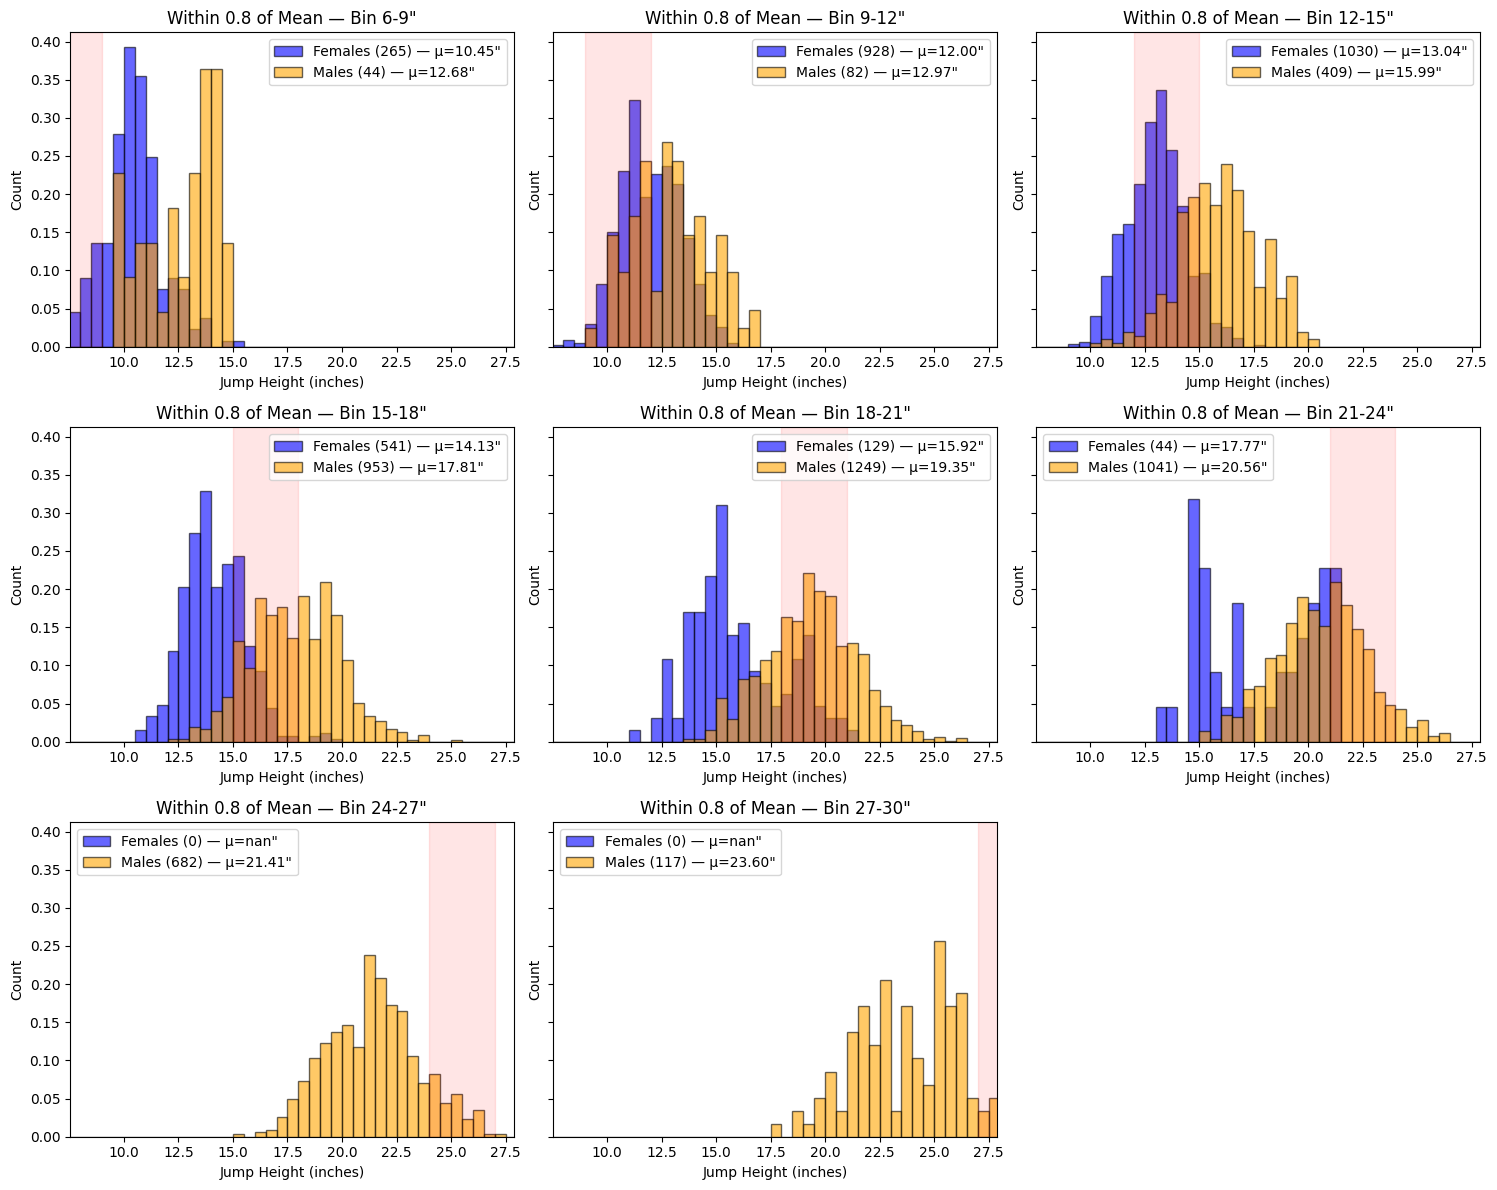

In [56]:
DISTANCE_THRESHOLD = 0.8

female_closest, female_overlap = get_closest_heights_by_bin(
    binned_females, "vae_latent_space_4d", "JUMP_HEIGHT_INCHES", "jump_bin", DISTANCE_THRESHOLD
)

male_closest, male_overlap = get_closest_heights_by_bin(
    binned_males, "vae_latent_space_4d", "JUMP_HEIGHT_INCHES", "jump_bin", DISTANCE_THRESHOLD
)
df
all_closest_heights = np.concatenate([
    np.concatenate(list(female_closest.values())),
    np.concatenate(list(male_closest.values()))
])
x_min, x_max = all_closest_heights.min(), all_closest_heights.max()

all_bins = sorted(set(female_closest.keys()) | set(male_closest.keys()), key=lambda x: int(x.split('-')[0]))
n_bins = len(all_bins)
ncols = 3
nrows = int(np.ceil(n_bins / ncols))

fig, axs = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), sharey=True)
axs = axs.flatten()

for i, bin_label in enumerate(all_bins):
    ax = axs[i]

    f_heights = female_closest.get(bin_label, [])
    m_heights = male_closest.get(bin_label, [])
    n_females = len(f_heights)
    n_males = len(m_heights)

    f_avg = np.mean(f_heights) if n_females > 0 else np.nan
    m_avg = np.mean(m_heights) if n_males > 0 else np.nan

    ax.hist(f_heights, bins=60, alpha=0.6, density=True, range=(0, 30),
            label=f'Females ({n_females}) — μ={f_avg:.2f}"', color='blue', edgecolor='black')
    ax.hist(m_heights, bins=60, alpha=0.6, density=True, range=(0, 30),
            label=f'Males ({n_males}) — μ={m_avg:.2f}"', color='orange', edgecolor='black')

    try:
        bin_start, bin_end = map(int, bin_label.split('-'))
        ax.axvspan(bin_start, bin_end, color='red', alpha=0.1)
    except ValueError:
        pass

    ax.set_title(f'Within {DISTANCE_THRESHOLD} of Mean — Bin {bin_label}"')
    ax.set_xlim(x_min, x_max)
    ax.set_xlabel("Jump Height (inches)")
    ax.set_ylabel("Count")
    ax.legend()

for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()


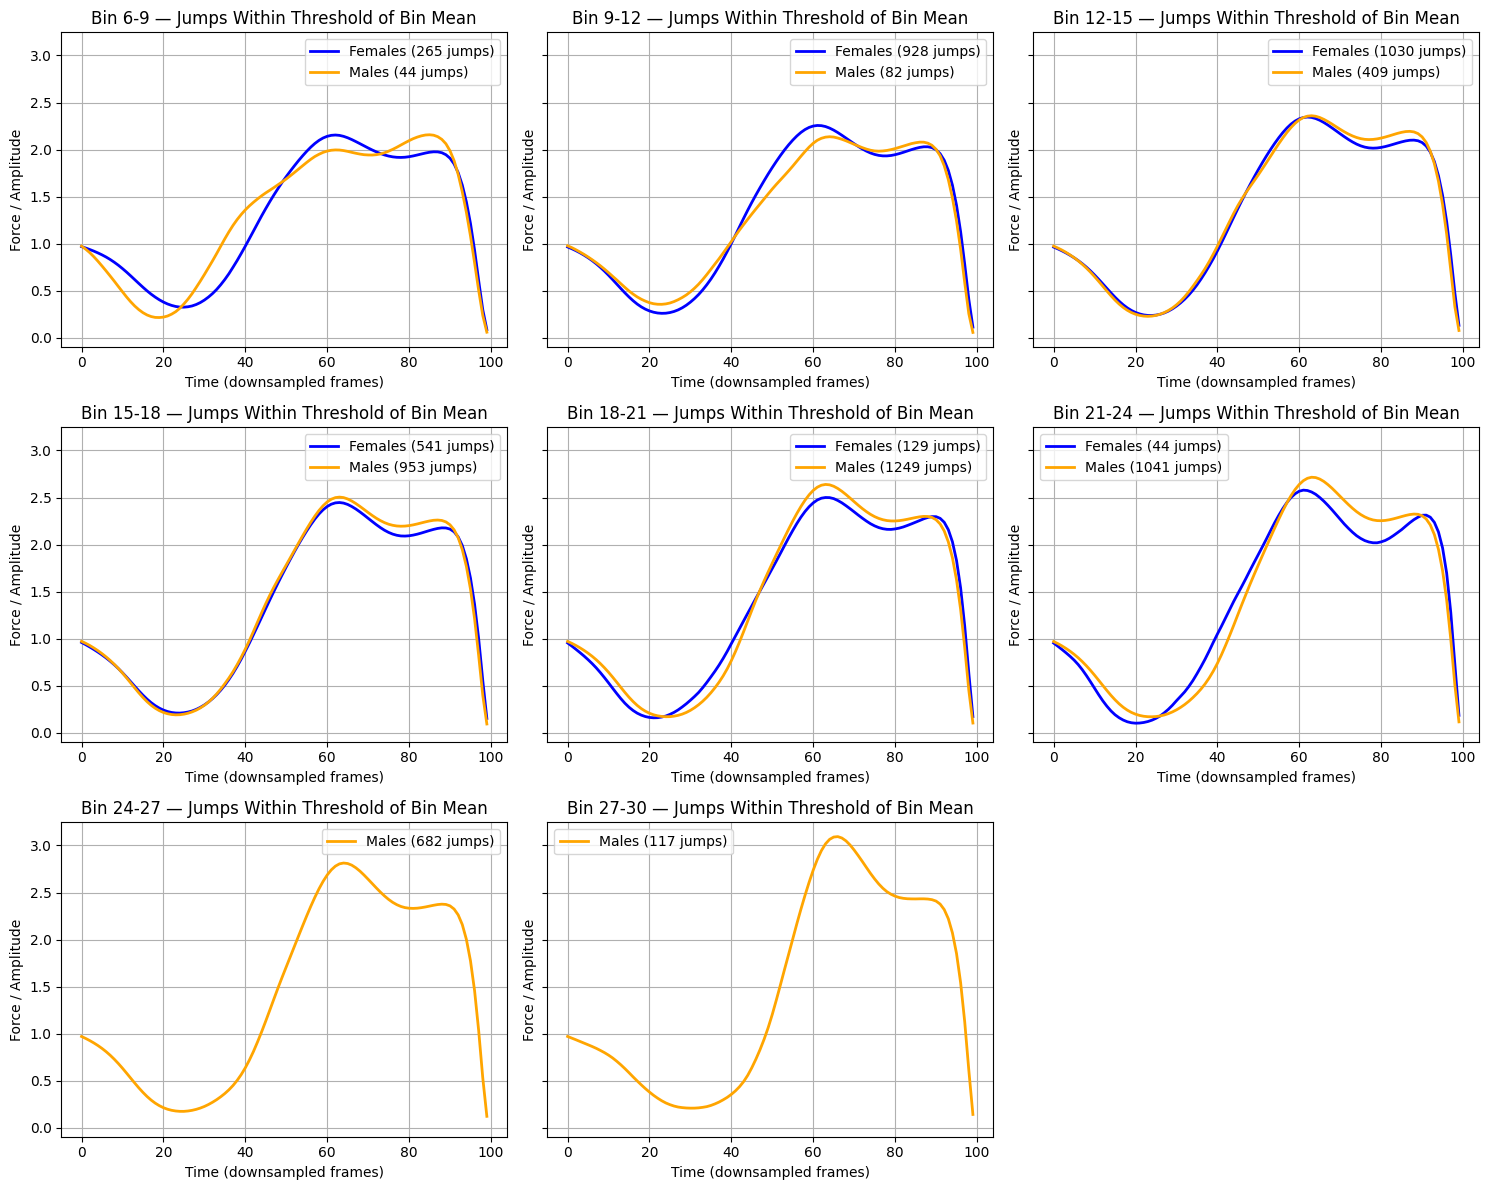

In [57]:
DISTANCE_THRESHOLD = 0.8

female_closest, female_overlap = get_closest_heights_by_bin(
    binned_females, "vae_latent_space_4d", "JUMP_HEIGHT_INCHES", "jump_bin", DISTANCE_THRESHOLD
)

male_closest, male_overlap = get_closest_heights_by_bin(
    binned_males, "vae_latent_space_4d", "JUMP_HEIGHT_INCHES", "jump_bin", DISTANCE_THRESHOLD
)

distance_threshold = 0.8

all_bins = sorted(set(female_closest.keys()) | set(male_closest.keys()), key=lambda x: int(x.split('-')[0]))
n_bins = len(all_bins)
ncols = 3
nrows = int(np.ceil(n_bins / ncols))

fig, axs = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), sharey=True)
axs = axs.flatten()


for i, bin_label in enumerate(all_bins):
    ax = axs[i]

    # Get current bin group (to compute the bin mean vector)
    f_bin_group = binned_females[binned_females["jump_bin"] == bin_label]
    m_bin_group = binned_males[binned_males["jump_bin"] == bin_label]

    f_bin_latents = np.stack(f_bin_group["vae_latent_space_4d"].values) if len(f_bin_group) > 0 else []
    m_bin_latents = np.stack(m_bin_group["vae_latent_space_4d"].values) if len(m_bin_group) > 0 else []

    f_mean_vector = f_bin_latents.mean(axis=0) if len(f_bin_latents) > 0 else np.nan
    m_mean_vector = m_bin_latents.mean(axis=0) if len(m_bin_latents) > 0 else np.nan

    # Compute distances from all jumps (not just in bin)
    f_all_latents = np.stack(binned_females["vae_latent_space_4d"].values)
    m_all_latents = np.stack(binned_males["vae_latent_space_4d"].values)

    f_all_distances = np.linalg.norm(f_all_latents - f_mean_vector, axis=1)
    m_all_distances = np.linalg.norm(m_all_latents - m_mean_vector, axis=1)

    # Filter based on distance threshold
    f_within_threshold = binned_females[f_all_distances < distance_threshold]
    m_within_threshold = binned_males[m_all_distances < distance_threshold]

    # Get time series for those jumps
    f_time_series_within_threshold = np.stack(f_within_threshold["downsampled_time_series"].values) if len(f_within_threshold) > 0 else []
    m_time_series_within_threshold = np.stack(m_within_threshold["downsampled_time_series"].values) if len(m_within_threshold) > 0 else []

    f_avg_time_series = f_time_series_within_threshold.mean(axis=0) if len(f_time_series_within_threshold) > 0 else np.nan
    m_avg_time_series = m_time_series_within_threshold.mean(axis=0) if len(m_time_series_within_threshold) > 0 else np.nan

    # Plot
    if len(f_time_series_within_threshold) > 0:
        ax.plot(f_avg_time_series, label=f'Females ({len(f_time_series_within_threshold)} jumps)', color='blue', linewidth=2)
        ax.grid(True)

    if len(m_time_series_within_threshold) > 0:
        ax.plot(m_avg_time_series, label=f'Males ({len(m_time_series_within_threshold)} jumps)', color='orange', linewidth=2)
        ax.grid(True)

    ax.set_title(f'Bin {bin_label} — Jumps Within Threshold of Bin Mean')
    ax.set_xlabel("Time (downsampled frames)")
    ax.set_ylabel("Force / Amplitude")
    ax.legend()


for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])
    
plt.tight_layout()

In [58]:
binned_males['peak_force'] = binned_males['downsampled_time_series'].apply(lambda x: np.max(x))
# binned_males['jump_duration'] = binned_males['jump_end_time'] - binned_males['jump_start_time']

feature_corr = binned_males[['peak_force', 'jump_end_time', 'JUMP_HEIGHT_INCHES']].corr()
print("Feature correlations with jump height:")
print(feature_corr)


Feature correlations with jump height:
                    peak_force  jump_end_time  JUMP_HEIGHT_INCHES
peak_force             1.00000      -0.329920            0.456940
jump_end_time         -0.32992       1.000000           -0.179317
JUMP_HEIGHT_INCHES     0.45694      -0.179317            1.000000


In [59]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

latent_matrix = np.stack(binned_males["vae_latent_space_4d"].values)

scaler = StandardScaler()
latent_matrix_scaled = scaler.fit_transform(latent_matrix)

k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(latent_matrix_scaled)


binned_males["cluster"] = cluster_labels

In [60]:
latent_matrix = np.stack(binned_females["vae_latent_space_4d"].values)

scaler = StandardScaler()
latent_matrix_scaled = scaler.fit_transform(latent_matrix)

kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(latent_matrix_scaled)


binned_females["cluster"] = cluster_labels

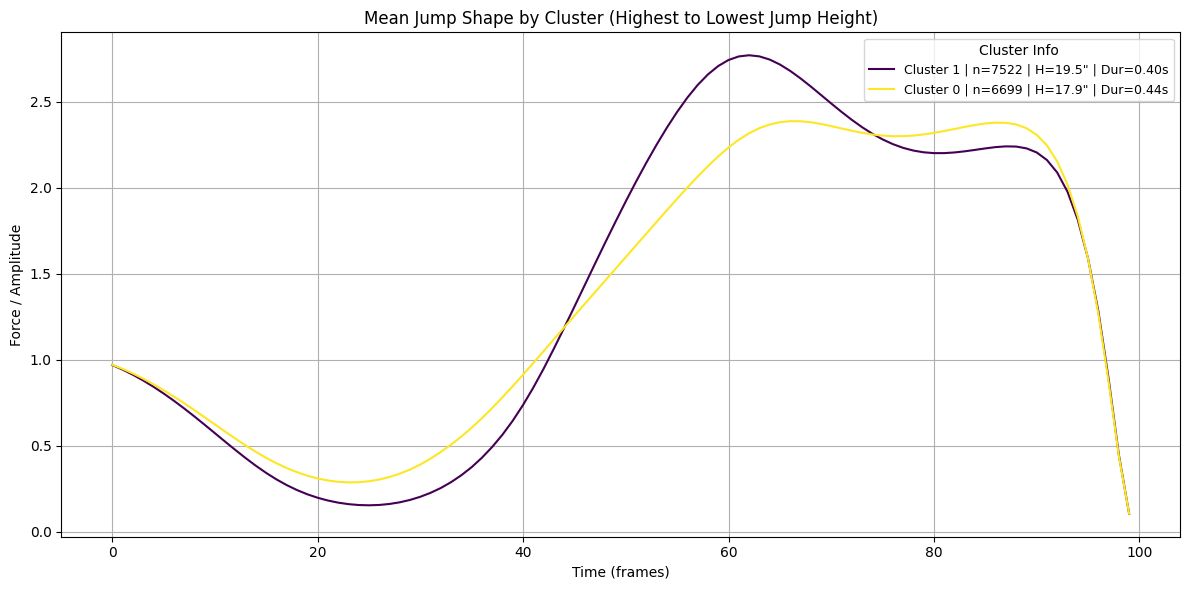

In [61]:
from matplotlib.cm import get_cmap

cluster_stats = []
for cluster_id in binned_males["cluster"].unique():
    cluster_group = binned_males[binned_males["cluster"] == cluster_id]
    mean_height = cluster_group["JUMP_HEIGHT_INCHES"].mean()
    cluster_stats.append((cluster_id, mean_height))

sorted_clusters = [cid for cid, _ in sorted(cluster_stats, key=lambda x: x[1], reverse=True)]

cmap = get_cmap("viridis", len(sorted_clusters))  

fig, ax = plt.subplots(figsize=(12, 6))

for idx, cluster_id in enumerate(sorted_clusters):
    cluster_group = binned_males[binned_males["cluster"] == cluster_id]
    mean_jump = np.stack(cluster_group["downsampled_time_series"].values).mean(axis=0)
    mean_height = cluster_group["JUMP_HEIGHT_INCHES"].mean()
    mean_duration = cluster_group["jump_end_time"].mean()
    n_samples = len(cluster_group)

    label = (f"Cluster {cluster_id} | n={n_samples} | "
             f"H={mean_height:.1f}\" | Dur={mean_duration:.2f}s")

    ax.plot(mean_jump, label=label, color=cmap(idx))

ax.set_title("Mean Jump Shape by Cluster (Highest to Lowest Jump Height)")
ax.set_xlabel("Time (frames)")
ax.set_ylabel("Force / Amplitude")
ax.legend(fontsize=9, title="Cluster Info")
ax.grid(True)
plt.tight_layout()
plt.show()


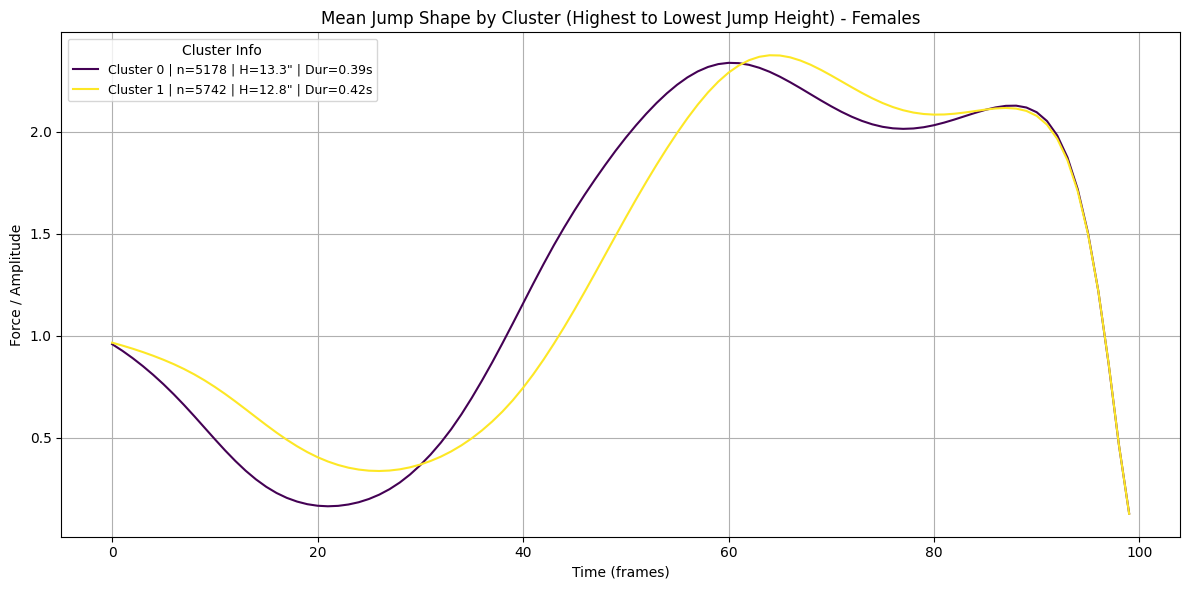

In [62]:
cluster_stats = []
for cluster_id in binned_females["cluster"].unique():
    cluster_group = binned_females[binned_females["cluster"] == cluster_id]
    mean_height = cluster_group["JUMP_HEIGHT_INCHES"].mean()
    cluster_stats.append((cluster_id, mean_height))

sorted_clusters = [cid for cid, _ in sorted(cluster_stats, key=lambda x: x[1], reverse=True)]

cmap = get_cmap("viridis", len(sorted_clusters))  

fig, ax = plt.subplots(figsize=(12, 6))

for idx, cluster_id in enumerate(sorted_clusters):
    cluster_group = binned_females[binned_females["cluster"] == cluster_id]
    mean_jump = np.stack(cluster_group["downsampled_time_series"].values).mean(axis=0)
    mean_height = cluster_group["JUMP_HEIGHT_INCHES"].mean()
    mean_duration = cluster_group["jump_end_time"].mean()
    n_samples = len(cluster_group)

    label = (f"Cluster {cluster_id} | n={n_samples} | "
             f"H={mean_height:.1f}\" | Dur={mean_duration:.2f}s")

    ax.plot(mean_jump, label=label, color=cmap(idx))

ax.set_title("Mean Jump Shape by Cluster (Highest to Lowest Jump Height) - Females")
ax.set_xlabel("Time (frames)")
ax.set_ylabel("Force / Amplitude")
ax.legend(fontsize=9, title="Cluster Info")
ax.grid(True)
plt.tight_layout()
plt.show()


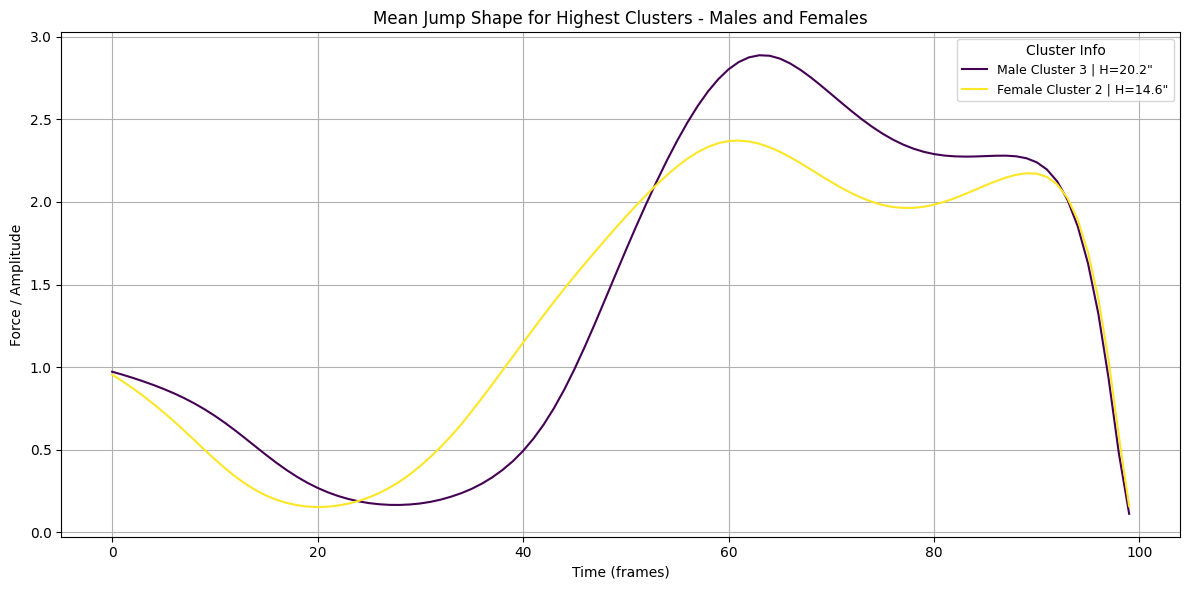

In [63]:
from matplotlib.cm import get_cmap

# Males - Cluster analysis
latent_matrix_males = np.stack(binned_males["vae_latent_space_4d"].values)
scaler = StandardScaler()
latent_matrix_scaled_males = scaler.fit_transform(latent_matrix_males)

k = 5
kmeans_males = KMeans(n_clusters=k, random_state=42)
cluster_labels_males = kmeans_males.fit_predict(latent_matrix_scaled_males)

binned_males["cluster"] = cluster_labels_males

# Sort male clusters by jump height
cluster_stats_males = []
for cluster_id in binned_males["cluster"].unique():
    cluster_group = binned_males[binned_males["cluster"] == cluster_id]
    mean_height = cluster_group["JUMP_HEIGHT_INCHES"].mean()
    cluster_stats_males.append((cluster_id, mean_height))

sorted_clusters_males = [cid for cid, _ in sorted(cluster_stats_males, key=lambda x: x[1], reverse=True)]

# Females - Cluster analysis
latent_matrix_females = np.stack(binned_females["vae_latent_space_4d"].values)
scaler = StandardScaler()
latent_matrix_scaled_females = scaler.fit_transform(latent_matrix_females)

k = 5
kmeans_females = KMeans(n_clusters=k, random_state=42)
cluster_labels_females = kmeans_females.fit_predict(latent_matrix_scaled_females)

binned_females["cluster"] = cluster_labels_females

# Sort female clusters by jump height
cluster_stats_females = []
for cluster_id in binned_females["cluster"].unique():
    cluster_group = binned_females[binned_females["cluster"] == cluster_id]
    mean_height = cluster_group["JUMP_HEIGHT_INCHES"].mean()
    cluster_stats_females.append((cluster_id, mean_height))

sorted_clusters_females = [cid for cid, _ in sorted(cluster_stats_females, key=lambda x: x[1], reverse=True)]

# Combine top clusters from both males and females
top_male_cluster_id = sorted_clusters_males[0]  # Highest male cluster
top_female_cluster_id = sorted_clusters_females[0]  # Highest female cluster

cmap = get_cmap("viridis", 2)  # Two clusters to plot

fig, ax = plt.subplots(figsize=(12, 6))

# Plot the highest male cluster
cluster_group_males = binned_males[binned_males["cluster"] == top_male_cluster_id]
mean_jump_male = np.stack(cluster_group_males["downsampled_time_series"].values).mean(axis=0)
ax.plot(mean_jump_male, label=f"Male Cluster {top_male_cluster_id} | H={cluster_group_males['JUMP_HEIGHT_INCHES'].mean():.1f}\"", color=cmap(0))

# Plot the highest female cluster
cluster_group_females = binned_females[binned_females["cluster"] == top_female_cluster_id]
mean_jump_female = np.stack(cluster_group_females["downsampled_time_series"].values).mean(axis=0)
ax.plot(mean_jump_female, label=f"Female Cluster {top_female_cluster_id} | H={cluster_group_females['JUMP_HEIGHT_INCHES'].mean():.1f}\"", color=cmap(1))

ax.set_title("Mean Jump Shape for Highest Clusters - Males and Females")
ax.set_xlabel("Time (frames)")
ax.set_ylabel("Force / Amplitude")
ax.legend(fontsize=9, title="Cluster Info")
ax.grid(True)
plt.tight_layout()
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


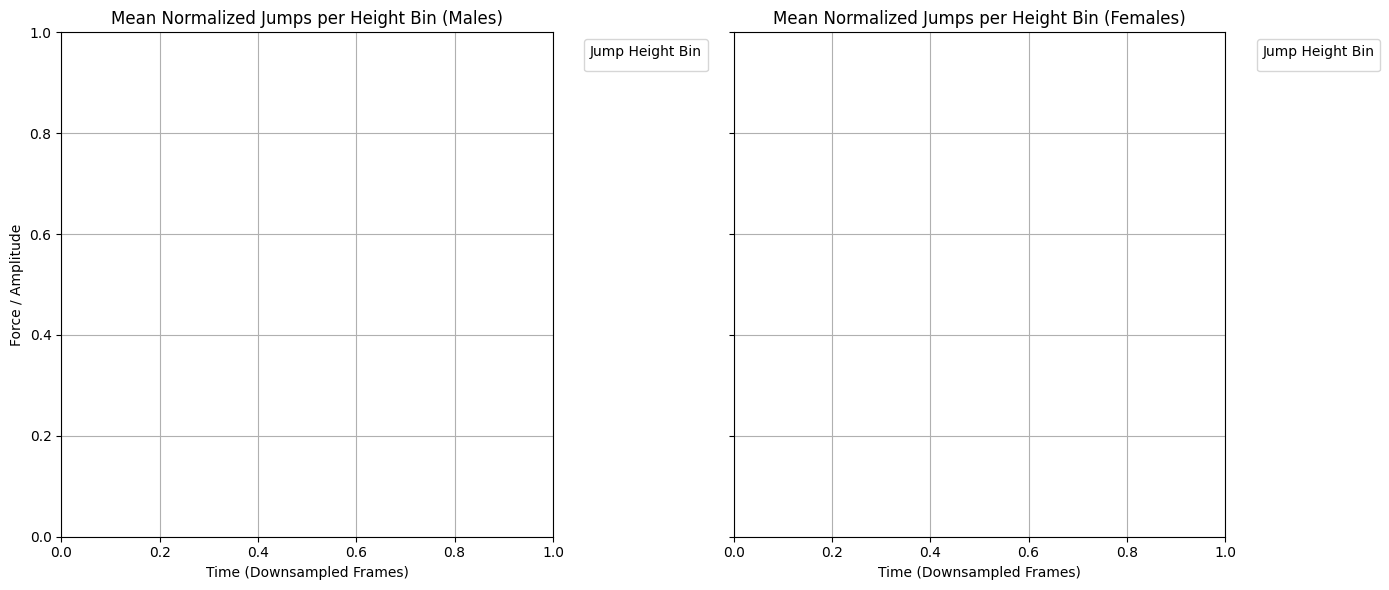

In [64]:
import matplotlib.pyplot as plt
import numpy as np
import math

# BIN_SIZE settings
BIN_SIZE_MALES = 6  # inches for males
BIN_SIZE_FEMALES = 4  # inches for females
MAX_JUMPS_PER_BIN = 120

# Create the bins for males (6 inches bin size)
min_height_males = math.floor(binned_males["JUMP_HEIGHT_INCHES"].min())
max_height_males = math.ceil(binned_males["JUMP_HEIGHT_INCHES"].max())
bins_males = np.arange(min_height_males, max_height_males + BIN_SIZE_MALES, BIN_SIZE_MALES)
bin_labels_males = [f"{int(b)}-{int(b + BIN_SIZE_MALES)}" for b in bins_males[:-1]]

# Create the bins for females (4 inches bin size)
min_height_females = math.floor(binned_females["JUMP_HEIGHT_INCHES"].min())
max_height_females = math.ceil(binned_females["JUMP_HEIGHT_INCHES"].max())
bins_females = np.arange(min_height_females, max_height_females + BIN_SIZE_FEMALES, BIN_SIZE_FEMALES)
bin_labels_females = [f"{int(b)}-{int(b + BIN_SIZE_FEMALES)}" for b in bins_females[:-1]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for bin_label in bin_labels_males:
    group = binned_males[binned_males["jump_bin"] == bin_label]
    if group.empty:
        continue

    group_sample = group.sample(n=min(MAX_JUMPS_PER_BIN, len(group)), random_state=42)

    try:
        jump_matrix = np.stack(group_sample["downsampled_time_series"].values)
        mean_jump = jump_matrix.mean(axis=0)
        ax1.plot(mean_jump, label=str(bin_label))
    except Exception as e:
        print(f"Skipping {bin_label} for males: {e}")

ax1.set_title("Mean Normalized Jumps per Height Bin (Males)")
ax1.set_xlabel("Time (Downsampled Frames)")
ax1.set_ylabel("Force / Amplitude")
ax1.legend(title="Jump Height Bin", bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True)

# Females (using 4 inch bins)
for bin_label in bin_labels_females:
    group = binned_females[binned_females["jump_bin"] == bin_label]
    if group.empty:
        continue

    group_sample = group.sample(n=min(MAX_JUMPS_PER_BIN, len(group)), random_state=42)

    try:
        jump_matrix = np.stack(group_sample["downsampled_time_series"].values)
        mean_jump = jump_matrix.mean(axis=0)
        ax2.plot(mean_jump, label=str(bin_label))
    except Exception as e:
        print(f"Skipping {bin_label} for females: {e}")

ax2.set_title("Mean Normalized Jumps per Height Bin (Females)")
ax2.set_xlabel("Time (Downsampled Frames)")
ax2.legend(title="Jump Height Bin", bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True)

plt.tight_layout()
plt.show()


In [65]:
# predict height based on latent variables
# why do we have curves so similar but jump height so different 
# take male jumper in 14 inch category and compare with nearest female neighbor in latent space
# find nearest neighbords in latent space of female
# 
males.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series,latent_space_consistency,reconstruction_loss,reconstruction,outlier,total_sessions,start_year,years_training,first_session_date,relative_session,latent_0,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,latent_11,latent_12,latent_13,latent_14,latent_15,initial_weight,year,jump_start,jump_end,jump_duration_s,jump_end_time,Gender,missing_body_weight,time_diff,takeoff_velocity,takeoff_velocity_2,tv_jump_height,tv_jump_height_2,vae_latent_space_4d
1438,0,0,adaee8b6-4ae7-4292-b7f4-8c1491cfb54c,1,b2cf3cb0-ec27-4a6a-b65c-0f0e86650797,2023-11-02 22:04:03.724000+00:00,Baseball,Sport,NaN,NaN,195.703714,35.34,35.828,35.532,35.678,17.514109,35.34,22.977109,22.176691,0.69,58.361826,56.314473,56.328765,108.007,result\nPOSITIVE_IMPULSE 845.683491\nPOSITI...,6433.102659,180.127,result\nLANDING_RFD 375447.617\nLANDING_RFD...,2.543,986.282,-0.143,108.007,result\nPEAK_LANDING_FORCE 10512.533271\nPE...,29926.697,0.838,117.813888,result\nLANDING_IMPULSE 89.352932\nLANDING_...,46380.0,

In [66]:
import statsmodels.api as sm

X_latent_4d = np.stack(males["jump_end_time"].values)
X_df = pd.DataFrame(X_latent_4d).reset_index(drop=True)

y = males["JUMP_HEIGHT_INCHES"].reset_index(drop=True)

X_with_const = sm.add_constant(X_df)

model = sm.OLS(y, X_with_const).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:     JUMP_HEIGHT_INCHES   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     472.4
Date:                Mon, 05 May 2025   Prob (F-statistic):          4.56e-103
Time:                        20:50:17   Log-Likelihood:                -34941.
No. Observations:               14221   AIC:                         6.989e+04
Df Residuals:                   14219   BIC:                         6.990e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         20.4297      0.081    251.540      0.0

In [67]:
binned_females.head(1)
# data["normalized_time_series"] = data["total_force"] / data["initial_value"]
# def process_jump_data(data, target_length=100):
#     """
#     Normalizes and resamples jump data.

#     Parameters:
#         data (torch.Tensor): Original data of shape [num_samples, time_steps]
#         target_length (int): Desired length for all jumps after resampling

#     Returns:
#         torch.Tensor: Processed data of shape [num_samples, target_length]
#     """
#     num_samples, original_length = data.shape
#     processed_data = []

#     for i in range(num_samples):
#         seq = data[i]
#         jump_end = find_jump_end(seq)

#         # Trim and interpolate
#         trimmed_seq = seq[:jump_end + 1].unsqueeze(0)  
#         resampled_seq = F.interpolate(trimmed_seq.unsqueeze(0), size=target_length, mode='linear', align_corners=False).squeeze(0).squeeze(0)

#         processed_data.append(resampled_seq)

#     return torch.stack(processed_data)

# target_length = 100  
# processed_data = process_jump_data(test_data, target_length)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series,latent_space_consistency,reconstruction_loss,reconstruction,outlier,total_sessions,start_year,years_training,first_session_date,relative_session,latent_0,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,latent_11,latent_12,latent_13,latent_14,latent_15,initial_weight,year,jump_start,jump_end,jump_duration_s,jump_end_time,Gender,missing_body_weight,time_diff,takeoff_velocity,takeoff_velocity_2,tv_jump_height,tv_jump_height_2,vae_latent_space_4d,jump_bin,cluster
0,0,0,f6b0b4f3-ccaa-488c-b71b-2a9d6fd8c359,1,eb037fd9-1b41-4bee-ade5-079f3d3012f8,2023-01-06 23:31:43.937000+00:00,Acro and Tumbling,Sport,NaN,NaN,121.271038,10.206,10.628,10.37,10.46,18.494496,10.206,8.676187,8.861041,0.424,22.037504,22.51405,22.507032,40.056,result\nPOSITIVE_IMPULSE 305.515939\nPOSITI...,2013.020207,124.807,result\nLANDING_RFD 44361.941\nLANDING_RFD ...,1.851,242.302,-0.095,40.056,result\nPEAK_LANDING_FORCE 2750.440318\nPEA...,3826.224,0.389,49.86295,result\nLANDING_IMPULSE 74.115300\nLAND

In [68]:
target_bin = "26-32"  
male_candidates = binned_males[binned_males["jump_bin"] == target_bin]

male_14_inch = male_candidates.sample(n=1).iloc[0]
male_latent = np.array(male_14_inch["vae_latent_space_4d"])
female_latents = np.stack(binned_females["vae_latent_space_4d"].values)
male_latent_rep = male_latent.reshape(1, -1)

dists = np.linalg.norm(female_latents - male_latent_rep, axis=1)

N_NEIGHBORS = 5
nearest_indices = np.argsort(dists)[:N_NEIGHBORS]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(male_14_inch["downsampled_time_series"], label=f"MALE - {male_14_inch['JUMP_HEIGHT_INCHES']:.1f}\" {male_14_inch['jump_end_time']}ms - {round(male_14_inch['tv_jump_height'] * 4, 2)}in", color='blue', linewidth=2.5)

for i, idx in enumerate(nearest_indices):
    female = binned_females.iloc[idx]
    curve = female["downsampled_time_series"]
    ax.plot(curve, label=f"FEMALE {i+1} - {female['JUMP_HEIGHT_INCHES']:.1f}\" - {female['jump_end_time']}ms {round(female['tv_jump_height'] * 4, 2)} in", linestyle='--', alpha=0.7)
    # print(female["jump_end_time"])

ax.set_title("Male Jump vs Nearest Female Jumps in Latent Space (Euclidean Distance)")
ax.set_xlabel("Downsampled Time Index")
ax.set_ylabel("Force / Amplitude")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

ValueError: a must be greater than 0 unless no samples are taken

In [ ]:
# target_bin = "14-20"  
# male_candidates = binned_males[binned_males["jump_bin"] == target_bin]
# 
# male_14_inch = male_candidates.sample(n=1).iloc[0]
# male_latent = np.array(male_14_inch["vae_latent_space_4d"])
# female_latents = np.stack(binned_females["vae_latent_space_4d"].values)
# male_latent_rep = male_latent.reshape(1, -1)

dists = np.linalg.norm(female_latents - male_latent_rep, axis=1)

N_NEIGHBORS = 5
nearest_indices = np.argsort(dists)[:N_NEIGHBORS]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(np.cumsum(np.array(male_14_inch["downsampled_time_series"]) - 1)*male_14_inch['jump_end_time'], label=f"MALE - {male_14_inch['JUMP_HEIGHT_INCHES_IMP_MOM']:.1f}\" {male_14_inch['jump_end_time']}ms - {round(male_14_inch['tv_jump_height'] * 4, 2)}in", color='blue', linewidth=2.5)

for i, idx in enumerate(nearest_indices):
    female = binned_females.iloc[idx]
    curve = np.cumsum(np.array(female["downsampled_time_series"]) - 1)*female["jump_end_time"]
    ax.plot(curve, label=f"FEMALE {i+1} - {female['JUMP_HEIGHT_INCHES_IMP_MOM']:.1f}\" - {female['jump_end_time']}ms {round(female['tv_jump_height'] * 4, 2)} in", linestyle='--', alpha=0.7)
    # print(female["jump_end_time"])

ax.set_title("Male Jump vs Nearest Female Jumps in Latent Space (Euclidean Distance)")
ax.set_xlabel("Downsampled Time Index")
ax.set_ylabel("Force / Amplitude")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Separate bins further, so for 12-18, separate by each inch, and look at the average jump shape for males and females of each of those jumps
# 

In [ ]:
target_bin = "14-20"  
male_candidates = binned_males[binned_males["jump_bin"] == target_bin]

male_14_inch = male_candidates.sample(n=1).iloc[0]
male_latent = np.array(male_14_inch["vae_latent_space_4d"])
male_latents = np.stack(binned_males["vae_latent_space_4d"].values)
male_latent_rep = male_latent.reshape(1, -1)

dists = np.linalg.norm(male_latents - male_latent_rep, axis=1)

N_NEIGHBORS = 5
nearest_indices = np.argsort(dists)[:N_NEIGHBORS]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(male_14_inch["downsampled_time_series"], label=f"MALE - {male_14_inch['JUMP_HEIGHT_INCHES']:.1f}\" {male_14_inch['jump_end_time']}ms", color='blue', linewidth=2.5)

for i, idx in enumerate(nearest_indices):
    male = binned_males.iloc[idx]
    curve = male["downsampled_time_series"]
    ax.plot(curve, label=f"MALE {i+1} - {male['JUMP_HEIGHT_INCHES']:.1f}\" - {male['jump_end_time']}ms", linestyle='--', alpha=0.7)
    # print(female["jump_end_time"])

ax.set_title("Male Jump vs Nearest Male Jumps in Latent Space (Euclidean Distance)")
ax.set_xlabel("Downsampled Time Index")
ax.set_ylabel("Force / Amplitude")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
target_bin = "14-18"
female_candidates = binned_females[binned_females["jump_bin"] == target_bin]

female_ref = female_candidates.sample(n=1).iloc[0]
female_latent = np.array(female_ref["vae_latent_space_4d"]).reshape(1, -1)

all_female_latents = np.stack(binned_females["vae_latent_space_4d"].values)

dists = np.linalg.norm(all_female_latents - female_latent, axis=1)

N_NEIGHBORS = 5
exclude_idx = binned_females.index.get_loc(female_ref.name)
dists[exclude_idx] = np.inf  # Ignore herself

nearest_indices = np.argsort(dists)[:N_NEIGHBORS]

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the selected female jump
ax.plot(
    female_ref["downsampled_time_series"],
    label=f"FEMALE - {female_ref['JUMP_HEIGHT_INCHES']:.1f}\" - {female_ref['jump_end_time']:.3f}s",
    color='purple',
    linewidth=2.5
)

for i, idx in enumerate(nearest_indices):
    neighbor = binned_females.iloc[idx]
    curve = neighbor["downsampled_time_series"]
    ax.plot(
        curve,
        label=f"NEIGHBOR {i+1} - {neighbor['JUMP_HEIGHT_INCHES']:.1f}\" - {neighbor['jump_end_time']:.3f}s",
        linestyle='--',
        alpha=0.7
    )

ax.set_title("Female Jump vs Nearest Female Jumps in Latent Space (Euclidean Distance)")
ax.set_xlabel("Downsampled Time Index")
ax.set_ylabel("Force / Amplitude")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()
